<div style="background:linear-gradient(135deg,#1a237e 0%,#283593 40%,#1565c0 100%);padding:35px;border-radius:15px;text-align:center;margin-bottom:20px;">
<h1 style="color:white;font-size:2.3em;margin:0;">🌍 Global Superstore — Complete EDA, Feature Engineering & ML</h1>
<p style="color:#90CAF9;font-size:1.1em;margin-top:10px;">Sales · Profit · Discount · Shipping · Market Analysis · Predictive Modelling</p>
</div>

---

## 🏆 What This Notebook Covers
- ✅ **Complete EDA** — 51,290 orders across 7 global markets, 13 regions
- ✅ **Time Series Analysis** — yearly and weekly sales/profit trends
- ✅ **Profitability Analysis** — which products, categories, and markets lose money
- ✅ **Discount Impact Analysis** — how discounting destroys profit margins
- ✅ **Feature Engineering** — 20+ engineered features
- ✅ **Feature Selection** — Random Forest importance scoring
- ✅ **5 ML Models** — Linear, Ridge, RF, XGBoost, GBM for profit prediction
- ✅ **Statistical Tests** — Kruskal-Wallis, Mann-Whitney U, Spearman
- ✅ **Business Report** — 16 actionable insights for retail strategy

---

## 📋 Table of Contents
| # | Section |
|---|---|
| 1 | [Setup & Data Loading](#s1) |
| 2 | [Data Cleaning & Preprocessing](#s2) |
| 3 | [Feature Engineering](#s3) |
| 4 | [Univariate Analysis](#s4) |
| 5 | [Sales & Profit Analysis](#s5) |
| 6 | [Category & Sub-Category Analysis](#s6) |
| 7 | [Market & Regional Analysis](#s7) |
| 8 | [Discount Impact Analysis](#s8) |
| 9 | [Time Series Analysis](#s9) |
| 10 | [Shipping Analysis](#s10) |
| 11 | [Correlation & Bivariate Analysis](#s11) |
| 12 | [Statistical Hypothesis Testing](#s12) |
| 13 | [Feature Selection](#s13) |
| 14 | [ML Models — Profit Prediction](#s14) |
| 15 | [Model Comparison & Selection](#s15) |
| 16 | [Key Insights & Business Report](#s16) |

> 💡 **If this notebook helped you, please upvote!** ⬆️


## Project Summary

Developed an end-to-end retail analytics and profit prediction system using the Global Superstore dataset (51K+ orders).

Key achievements:

* Performed comprehensive EDA and hypothesis testing.
* Identified discounting as the primary driver of profit loss.
* Engineered business-focused features for profit prediction.
* Compared ElasticNet, Random Forest, Gradient Boosting, and XGBoost models.
* Built an ensemble model achieving R² ≈ 0.76 on a holdout test year.
* Generated actionable business recommendations for pricing, discounting, and category optimization.


## 1. Setup & Data Loading 🔧 <a id='s1'></a>

In [1]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'Pandas {pd.__version__} | NumPy {np.__version__} | XGBoost: {XGB_AVAILABLE}')
print('All libraries loaded!')


Pandas 2.3.3 | NumPy 2.4.6 | XGBoost: True
All libraries loaded!


# Dataset Upload

In [2]:
def load_dataset():
    # Loading the dataset
    
    path = '/kaggle/input/datasets/sumeakash/enhanced-superstore-sales-dataset/Global Superstore.csv'
    
    try:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print('Dataset load successfully')
            return df
            
        else:
            print('File not exist')
            
    except Exception as e:
        raise Exception(f'error:{e}')

df = load_dataset()
df.head()

Dataset load successfully


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


# Dataset Details

In [3]:
def basic_details(df):

    print('=' * 60)
    print('The shape of dataset is:')
    print(df.shape)

    print('=' * 60)
    print('The features are:')
    print(df.columns.tolist())

    print('=' * 60)
    print('The feature types are:')
    df.info()

    print('=' * 60)
    print('The total duplicate rows are:')
    print(df.duplicated().sum())

    print('=' * 60)

    missing_value = df.isnull().sum()

    missing_percent = (missing_value / len(df)) * 100


    missing = pd.DataFrame({
        'Missing Value': missing_value,
        'Missing Percent': missing_percent
    })

    print('Information about missing data and unique value:')
    print(missing)

    print('=' * 60)

    cat_cols = df.select_dtypes(include='object').columns

    cat_summary = pd.DataFrame({
    'Unique Values': df[cat_cols].nunique(),
    'Most Frequent': df[cat_cols].mode().iloc[0]
    })

    print('The information about categeory features: ')
    print(cat_summary)

basic_details(df)

The shape of dataset is:
(51290, 27)
The features are:
['Category', 'City', 'Country', 'Customer ID', 'Customer Name', 'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID', 'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum']
The feature types are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non

## 2. Data Cleaning & Preprocessing 🧹 <a id='s2'></a>

<div style="background:#fff8e1;padding:12px;border-left:4px solid #f39c12;border-radius:5px; color: #0066cc;">
<b>Key steps:</b> Drop redundant ID columns, fix Sales=0 rows, create profit margin, encode categoricals.
</div>


Negative Sales: 0
Negative Quantity: 0
Negative Shipping Cost: 0


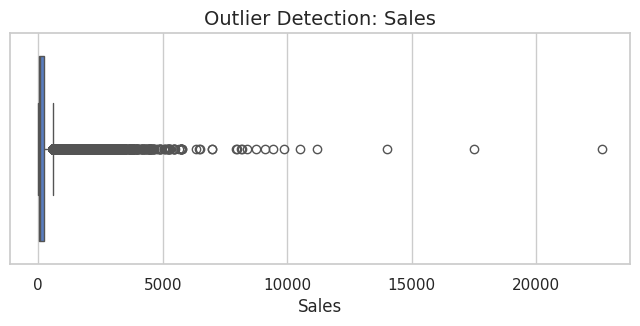

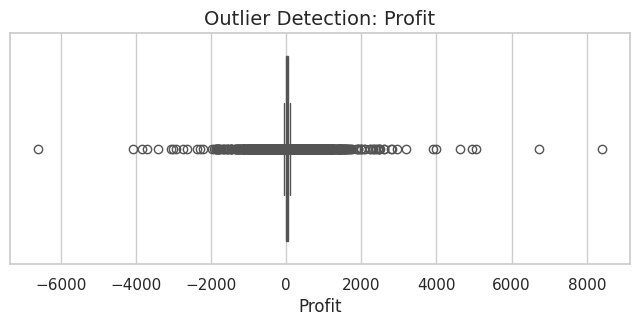

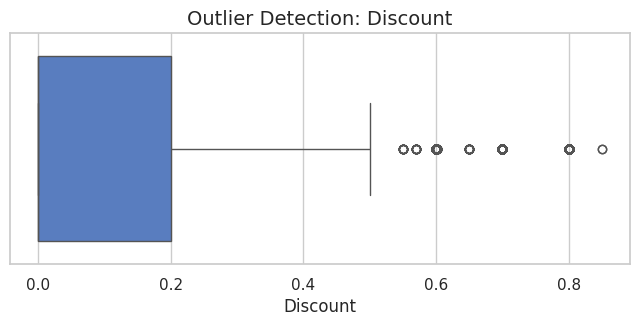

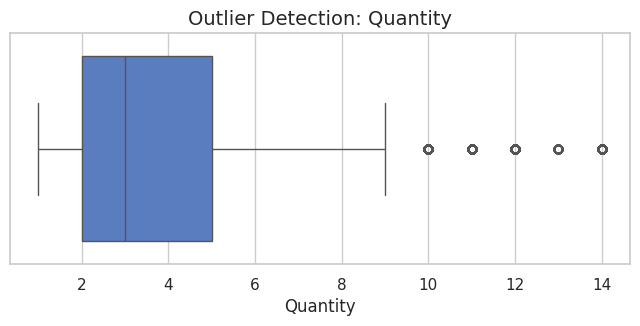

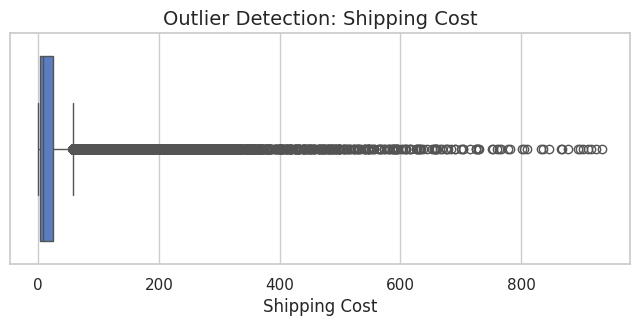

In [4]:
important_cols = [
    'Sales',
    'Profit',
    'Discount',
    'Quantity',
    'Shipping Cost'
]

#check incorrect data if exists
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Negative Shipping Cost:", (df['Shipping Cost'] < 0).sum())

for col in important_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection: {col}')
    plt.show()


Category
['Office Supplies' 'Technology' 'Furniture']

Segment
['Consumer' 'Home Office' 'Corporate']

Ship Mode
['Second Class' 'Standard Class' 'Same Day' 'First Class']

Order Priority
['High' 'Medium' 'Critical' 'Low']

Sub-Category
['Paper' 'Art' 'Storage' 'Appliances' 'Supplies' 'Envelopes' 'Fasteners'
 'Labels' 'Binders' 'Accessories' 'Phones' 'Copiers' 'Machines' 'Tables'
 'Bookcases' 'Chairs' 'Furnishings']


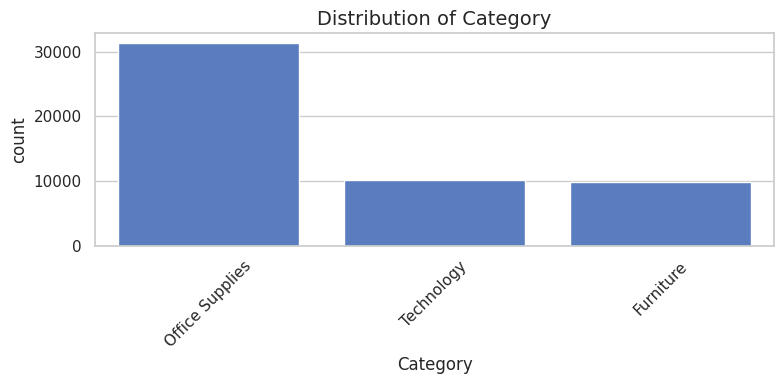

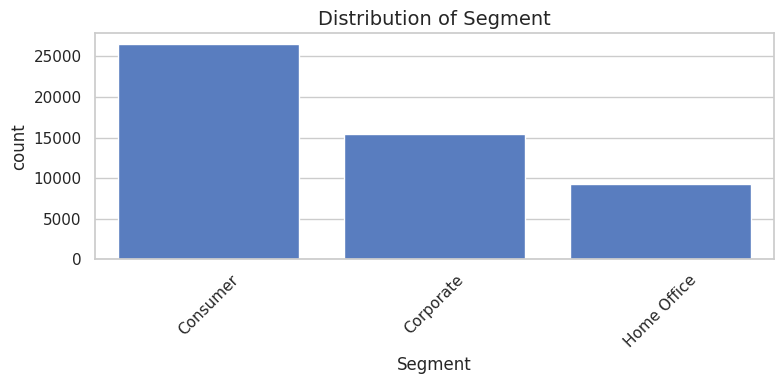

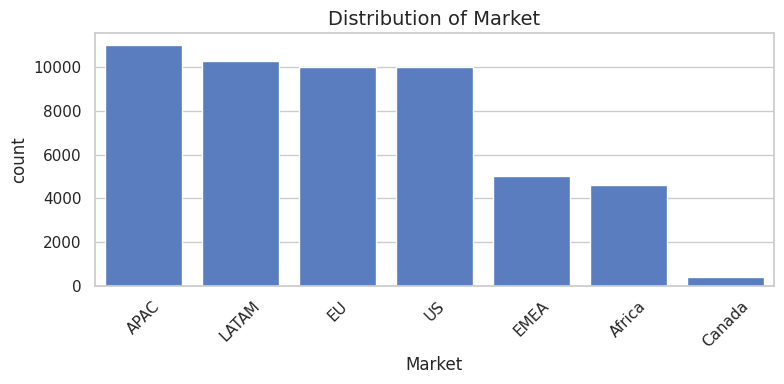

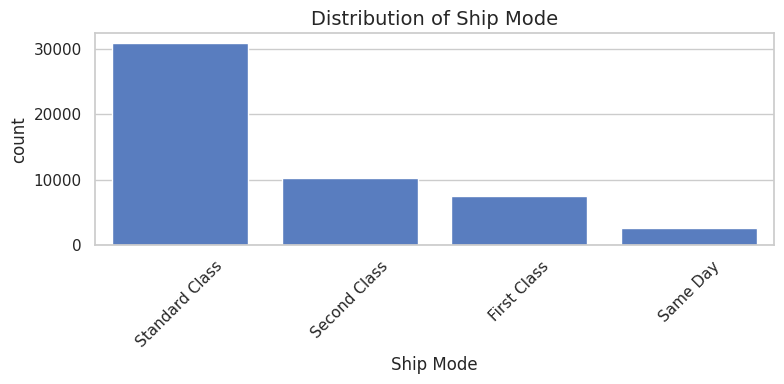

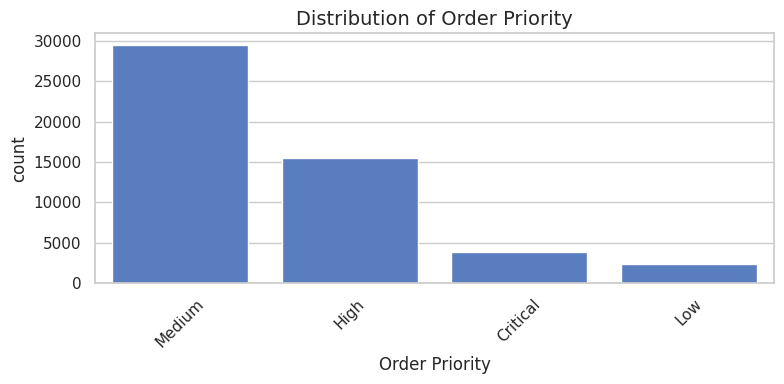

In [5]:
important_cat_cols = [
    'Category',
    'Segment',
    'Market',
    'Ship Mode',
    'Order Priority'
]


#check incorrect data if exists
for col in ['Category', 'Segment', 'Ship Mode', 'Order Priority','Sub-Category',]:
    print(f"\n{col}")
    print(df[col].unique())


for col in important_cat_cols:
    plt.figure(figsize=(8, 4))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order
    )

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
def data_cleaning_and_feature_extract(df):
    # ============================================================
    # SECTION 2 — Data Cleaning
    # ============================================================
    df = df.copy()

    # Feature engineering first
    df['Ship Date'] = pd.to_datetime(df['Ship Date'])
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['shipping_days'] = (
    df['Ship Date'] - df['Order Date']
    ).dt.days


    # Drop redundant columns
    drop_cols = ['Row ID','Customer ID','Order ID','Product ID','Customer Name',
             'Product Name','City','State','Country','Order Date','Ship Date',
             'ji_lu-shu','Market2']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Remove zero-sales rows (avoid division by zero)
    df = df[df['Sales'] > 0].copy()

    # Derived financial metrics
    df['profit_margin']    = (df['Profit'] / df['Sales']).clip(-5, 5)
    df['revenue_per_unit'] = df['Sales'] / df['Quantity']
    df['profit_per_unit']  = df['Profit'] / df['Quantity']
    df['is_profitable']    = (df['Profit'] > 0).astype(int)
    df['is_loss']          = (df['Profit'] < 0).astype(int)

    print(f'Clean shape : {df.shape}')
    print(f'Missing     : {df.isnull().sum().sum()}')
    print(f'Profitable orders : {df["is_profitable"].sum():,} ({df["is_profitable"].mean()*100:.1f}%)')
    print(f'Loss orders       : {df["is_loss"].sum():,} ({df["is_loss"].mean()*100:.1f}%)')

    return df

df = data_cleaning_and_feature_extract(df)


Clean shape : (51289, 20)
Missing     : 0
Profitable orders : 38,078 (74.2%)
Loss orders       : 12,543 (24.5%)


**The dataset shows that the company is generally profitable, with approximately 74% of orders generating positive profit. However, nearly 25% of transactions resulted in losses.**

In [7]:
# Descriptive statistics
df[['Sales','Profit','Discount','Quantity','Shipping Cost','profit_margin']].describe().T.round(3).style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
Sales,51289.000000,246.503000,487.571000,1.000000,31.000000,85.000000,251.000000,22638.000000
Profit,51289.000000,28.612000,174.343000,-6599.978000,0.000000,9.240000,36.810000,8399.976000
Discount,51289.000000,0.143000,0.212000,0.000000,0.000000,0.000000,0.200000,0.850000
Quantity,51289.000000,3.477000,2.279000,1.000000,2.000000,3.000000,5.000000,14.000000
Shipping Cost,51289.000000,26.376000,57.297000,0.002000,2.610000,7.790000,24.450000,933.570000
profit_margin,51289.000000,0.047000,0.467000,-4.728000,0.000000,0.169000,0.333000,0.583000


## 3. Feature Engineering 🛠️ <a id='s3'></a>

<div style="background:#f0fff0;padding:12px;border-left:4px solid #27ae60;border-radius:5px;color: #0066cc;">
We engineer <b>20+ features</b> from categories, discounts, shipping, and financial ratios.
</div>


In [8]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# Discount buckets
def disc_bucket(d):
    if d == 0:   return '0_none'
    if d <= 0.1: return '1_low'
    if d <= 0.3: return '2_medium'
    if d <= 0.5: return '3_high'
    return '4_extreme'
def feature_extraction(df):
    
    df = df.copy()
    
    df['discount_bucket'] = df['Discount'].apply(disc_bucket)
    df['has_discount']    = (df['Discount'] > 0).astype(int)
    df['high_discount']   = (df['Discount'] > 0.3).astype(int)

    # Category flags
    df['is_technology']      = (df['Category'] == 'Technology').astype(int)
    df['is_furniture']       = (df['Category'] == 'Furniture').astype(int)
    df['is_office_supplies'] = (df['Category'] == 'Office Supplies').astype(int)

    # Segment flags
    df['is_consumer']    = (df['Segment'] == 'Consumer').astype(int)
    df['is_corporate']   = (df['Segment'] == 'Corporate').astype(int)
    df['is_home_office'] = (df['Segment'] == 'Home Office').astype(int)

    # Market flags
    df['is_us']    = (df['Market'] == 'US').astype(int)
    df['is_eu']    = (df['Market'] == 'EU').astype(int)
    df['is_apac']  = (df['Market'] == 'APAC').astype(int)
    df['is_latam'] = (df['Market'] == 'LATAM').astype(int)

    # Shipping flags 
    df['is_same_day']    = (df['Ship Mode'] == 'Same Day').astype(int)
    df['is_first_class'] = (df['Ship Mode'] == 'First Class').astype(int)
    df['is_standard']    = (df['Ship Mode'] == 'Standard Class').astype(int)

    # Priority flags
    df['is_critical'] = (df['Order Priority'] == 'Critical').astype(int)

    # Log transforms
    df['log_sales']         = np.log1p(df['Sales'])
    df['log_shipping_cost'] = np.log1p(df['Shipping Cost'])

    print(f'Total features: {len(df.columns)}')
    df[['Sales','Profit','Discount','profit_margin','discount_bucket','is_technology']].head(5)


    return df

df = feature_extraction(df)

Total features: 39


## 4. Univariate Analysis 📊 <a id='s4'></a>

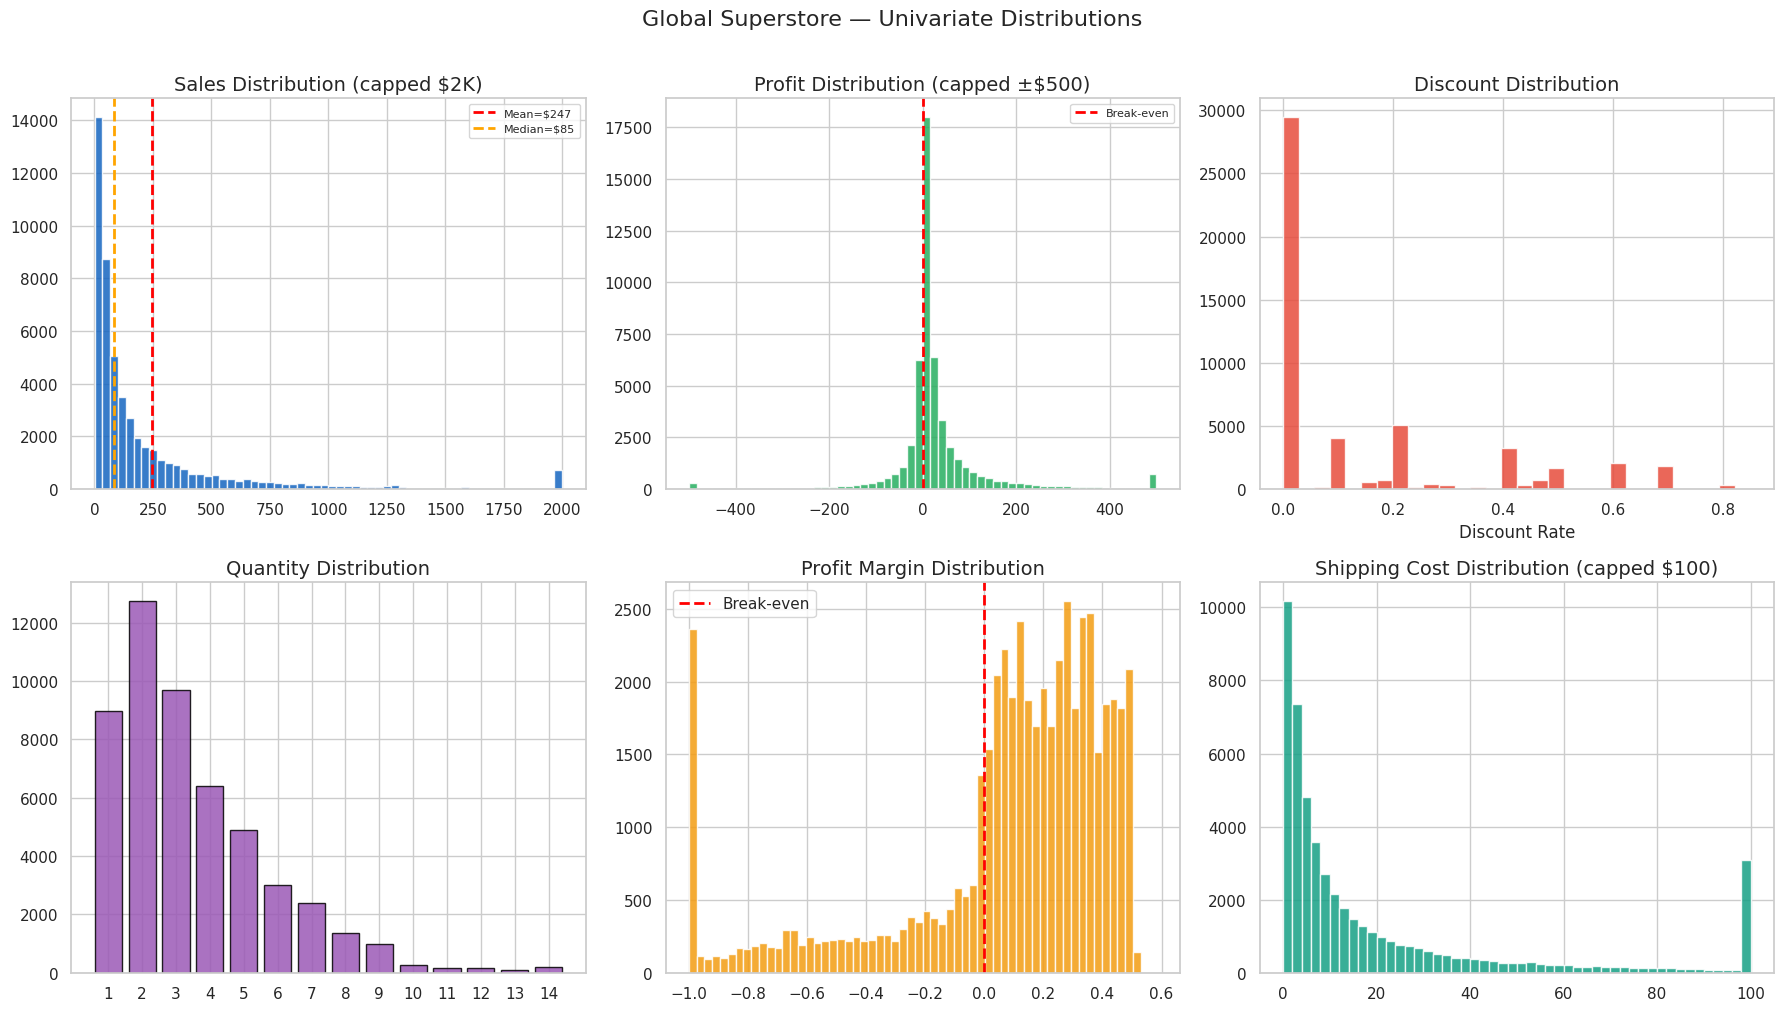

In [9]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df['Sales'].clip(upper=2000), bins=60, color='#1565c0', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['Sales'].mean(), color='red', linestyle='--', lw=2, label=f'Mean=${df["Sales"].mean():.0f}')
axes[0,0].axvline(df['Sales'].median(), color='orange', linestyle='--', lw=2, label=f'Median=${df["Sales"].median():.0f}')
axes[0,0].set_title('Sales Distribution (capped $2K)'); axes[0,0].legend(fontsize=8)

axes[0,1].hist(df['Profit'].clip(-500, 500), bins=60, color='#27ae60', edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='red', linestyle='--', lw=2, label='Break-even')
axes[0,1].set_title('Profit Distribution (capped ±$500)'); axes[0,1].legend(fontsize=8)

axes[0,2].hist(df['Discount'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Discount Distribution'); axes[0,2].set_xlabel('Discount Rate')

qty_counts = df['Quantity'].value_counts().sort_index()
axes[1,0].bar(qty_counts.index.astype(str), qty_counts.values, color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Quantity Distribution')

axes[1,1].hist(df['profit_margin'].clip(-1, 1), bins=60, color='#f39c12', edgecolor='white', alpha=0.85)
axes[1,1].axvline(0, color='red', linestyle='--', lw=2, label='Break-even')
axes[1,1].set_title('Profit Margin Distribution'); axes[1,1].legend()

axes[1,2].hist(df['Shipping Cost'].clip(upper=100), bins=50, color='#16a085', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Shipping Cost Distribution (capped $100)')

plt.suptitle('Global Superstore — Univariate Distributions', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()


1️)Sales Distribution -> Most orders contain relatively low sales values, while a small number of transactions contribute very high sales amounts.                              

2)Profit Distribution -> Most transactions generated small positive profits, although some orders high profits and some order high losses.                                   


3)Discount Distribution -> The discount distribution plot shows how frequently different discount rates were applied across orders. Most transactions received little or no discount, while higher discount levels were used less frequently.                 

4)Quantity Distribution -> Most customers purchase small quantities (1–4 items) and
large quantity orders are rare.                                                        


5)Profit Margin Distribution ->Many orders have positive margins and some orders have negative margins (losses).
Red line at 0 = no profit/no loss.                                                      

6)Shipping Cost Distribution -> Shipping costs are generally low for most orders, with a limited number of transactions incurring very high delivery expenses





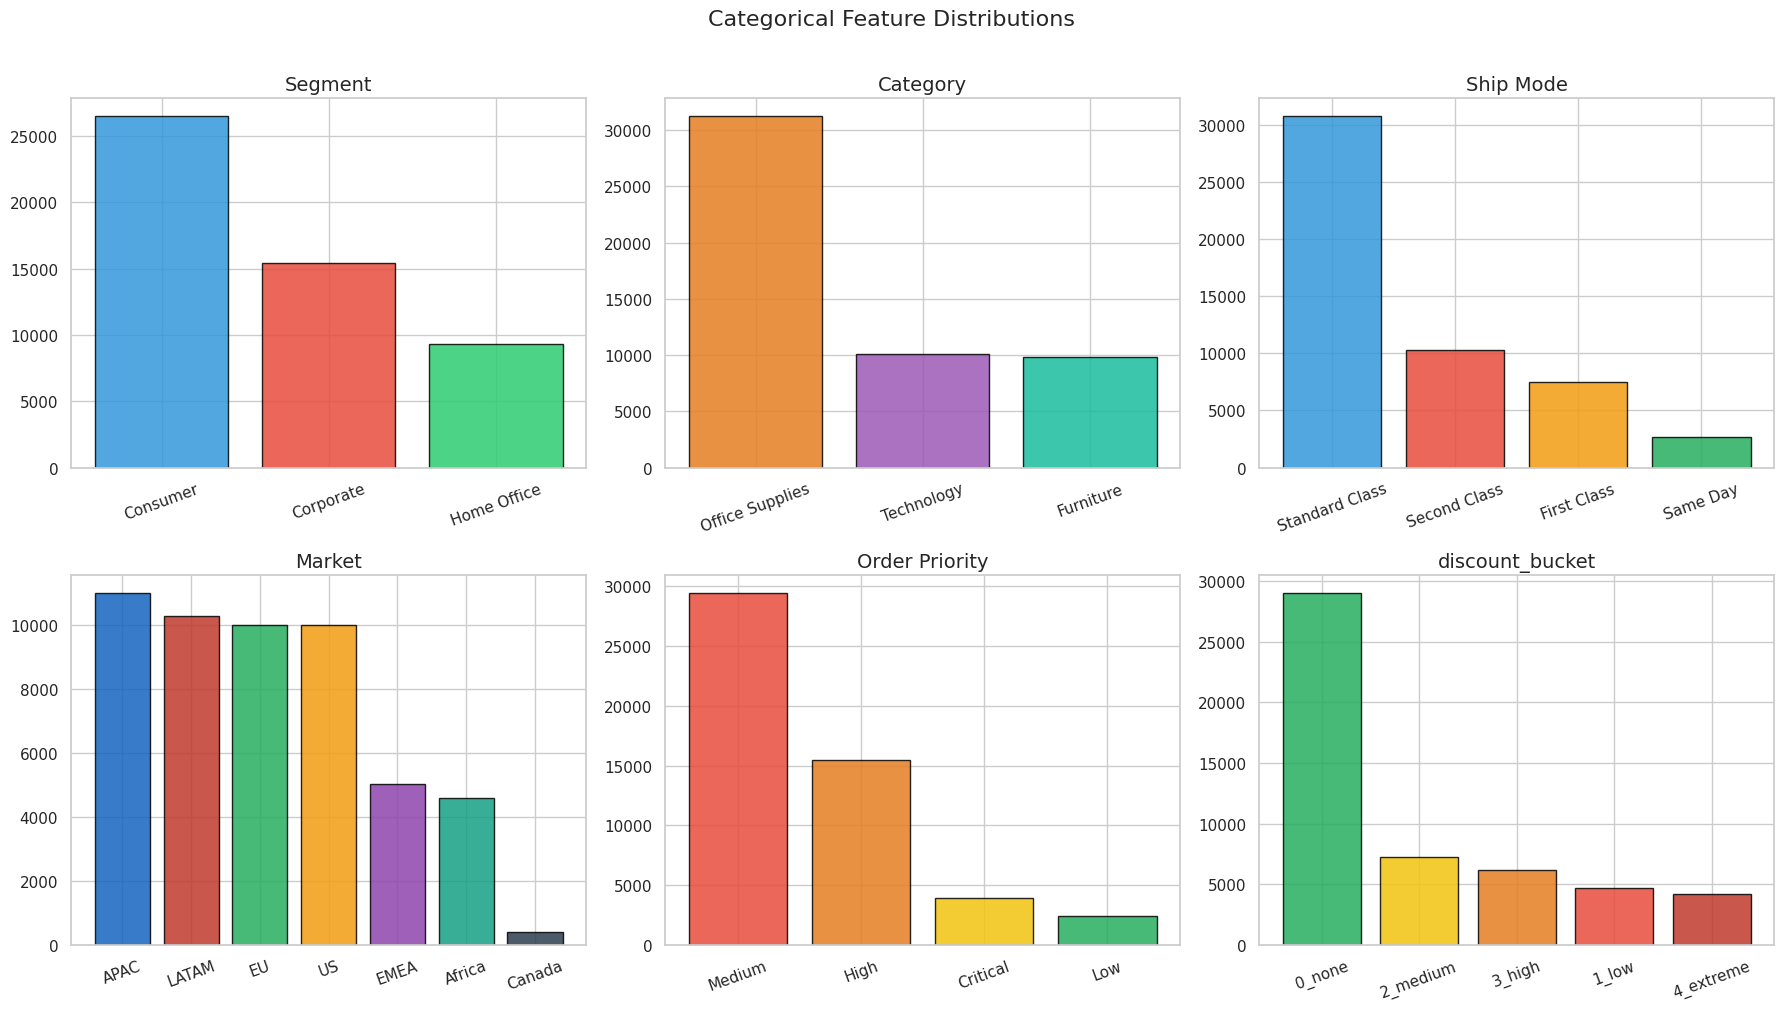

In [10]:
# Categorical distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cats = [
    ('Segment',        ['#3498db','#e74c3c','#2ecc71']),
    ('Category',       ['#e67e22','#9b59b6','#1abc9c']),
    ('Ship Mode',      ['#3498db','#e74c3c','#f39c12','#27ae60']),
    ('Market',         ['#1565c0','#c0392b','#27ae60','#f39c12','#8e44ad','#16a085','#2c3e50']),
    ('Order Priority', ['#e74c3c','#e67e22','#f1c40f','#27ae60']),
    ('discount_bucket',['#27ae60','#f1c40f','#e67e22','#e74c3c','#c0392b']),
]
for ax, (col, colors) in zip(axes.flatten(), cats):
    #axes.flatten() -> converts subplot matrix into simple list.
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black', alpha=0.85)
    ax.set_title(col); ax.tick_params(axis='x', rotation=20)
plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()


## 5. Sales & Profit Analysis 💰 <a id='s5'></a>

<div style="background:#fff8e1;padding:12px;border-left:4px solid #f39c12;border-radius:5px;color: #0066cc;">
<b>Key question:</b> Where is the money being made — and lost?
</div>


ROI = (Profit/Sales)×100
ROI shows how much profit the company earns for every dollar of sales.

In [11]:
# ============================================================
# SECTION 5 — Sales & Profit Analysis
# ============================================================
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
print('='*55)
print('KEY PERFORMANCE INDICATORS')
print('='*55)
print(f'  Total Revenue     : ${total_sales:>12,.0f}')
print(f'  Total Profit      : ${total_profit:>12,.0f}')
print(f'  Total Orders      : {len(df):>12,}')
print(f'  Overall ROI       : {total_profit/total_sales*100:>11.1f}%')
print(f'  Loss-making Orders: {df["is_loss"].sum():>12,} ({df["is_loss"].mean()*100:.1f}%)')


KEY PERFORMANCE INDICATORS
  Total Revenue     : $  12,642,905
  Total Profit      : $   1,467,458
  Total Orders      :       51,289
  Overall ROI       :        11.6%
  Loss-making Orders:       12,543 (24.5%)


Overall ROI -> It shows how much profit the company earned compared to total sales/investment.


Across the complete dataset, the company earned about 11.6% profit relative to total sales

In [12]:
yearly_roi = (
    df.groupby('Year')
      .apply(
          lambda x: (
              x['Profit'].sum() /
              x['Sales'].sum()
          ) * 100
      )
      .reset_index(name='ROI')
)

print(yearly_roi)

   Year        ROI
0  2011  11.017464
1  2012  11.481460
2  2013  11.948090
3  2014  11.724704


ROI remained relatively stable across all years, fluctuating around 11–12%, with the highest ROI observed in 2013.

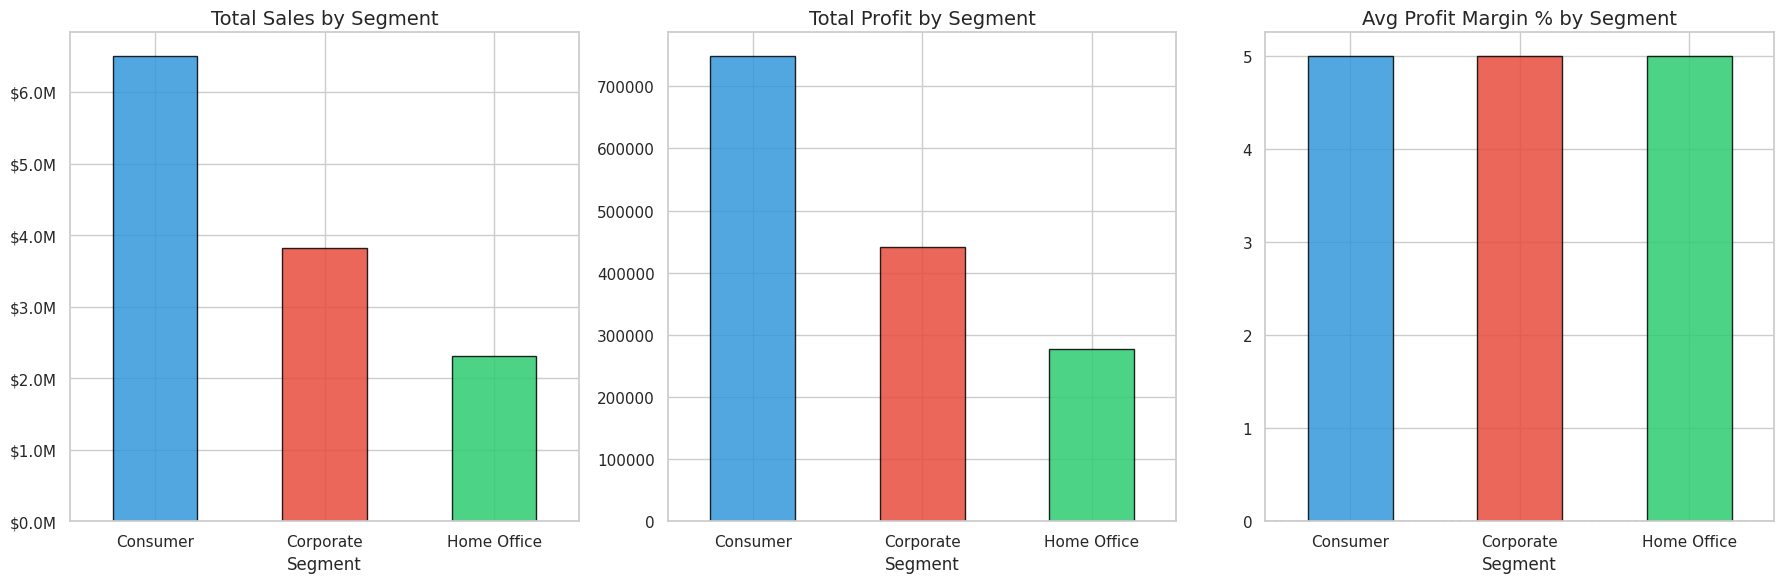

             Total_Sales  Total_Profit  Avg_Margin  Orders
Segment                                                   
Consumer         6508141     749240.89        0.05   26517
Corporate        3824808     441208.33        0.05   15429
Home Office      2309956     277009.18        0.05    9343


In [13]:
# Sales and Profit by Segment
seg_stats = df.groupby('Segment').agg(
    Total_Sales=('Sales','sum'), Total_Profit=('Profit','sum'),
    Avg_Margin=('profit_margin','mean'), Orders=('Sales','count')).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
seg_colors = ['#3498db','#e74c3c','#2ecc71']

seg_stats['Total_Sales'].plot.bar(ax=axes[0], color=seg_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Total Sales by Segment'); axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

seg_stats['Total_Profit'].plot.bar(ax=axes[1], color=seg_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Total Profit by Segment'); axes[1].tick_params(axis='x', rotation=0)

(seg_stats['Avg_Margin']*100).plot.bar(ax=axes[2], color=seg_colors, edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Profit Margin % by Segment'); axes[2].tick_params(axis='x', rotation=0)
axes[2].axhline(0, color='red', linestyle='--', lw=1)

plt.tight_layout(); plt.show()
print(seg_stats.to_string())


All customer segments maintained a similar average profit margin of approximately 5%, indicating relatively consistent profitability across segments.

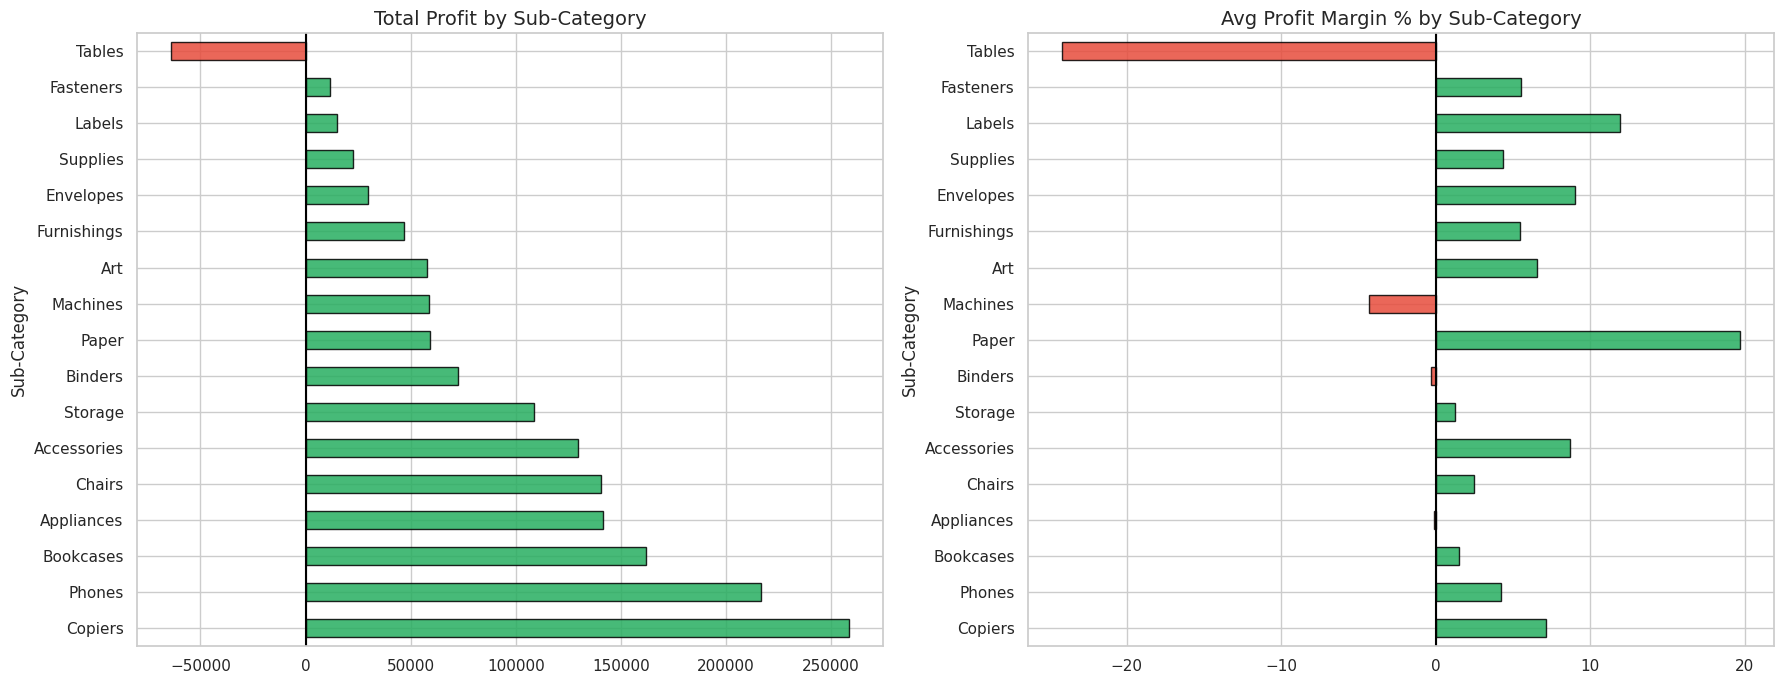

Loss-making sub-categories: 1
              Total_Sales  Total_Profit  Avg_Margin  Orders
Sub-Category                                               
Tables             757034   -64083.3887   -0.242099     861


In [14]:
# Sub-category profitability
subcat_stats = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales','sum'), Total_Profit=('Profit','sum'),
    Avg_Margin=('profit_margin','mean'), Orders=('Sales','count')
).sort_values('Total_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors_p = ['#27ae60' if v > 0 else '#e74c3c' for v in subcat_stats['Total_Profit']]
subcat_stats['Total_Profit'].plot.barh(ax=axes[0], color=colors_p, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', lw=1.5) #lw -> thickness of line
axes[0].set_title('Total Profit by Sub-Category')

colors_m = ['#27ae60' if v > 0 else '#e74c3c' for v in subcat_stats['Avg_Margin']]
(subcat_stats['Avg_Margin']*100).plot.barh(ax=axes[1], color=colors_m, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_title('Avg Profit Margin % by Sub-Category')

plt.tight_layout(); plt.show()
loss_sc = subcat_stats[subcat_stats['Total_Profit'] < 0]
print(f'Loss-making sub-categories: {len(loss_sc)}')
print(loss_sc[['Total_Sales','Total_Profit','Avg_Margin','Orders']].to_string())


The sub-category analysis reveals that Copiers are the most profitable products, while Tables are the largest loss-making sub-category. In terms of profitability efficiency, Paper achieved the highest average profit margin, whereas Tables showed the weakest margin performance with significant negative profitability.                            




### Business Insight

Although the Tables sub-category generated approximately 757K USD in sales from 861 orders, it still produced an overall loss of nearly 64K USD with a negative average profit margin of -24.2%.

## 6. Category & Sub-Category Analysis 🗂️ <a id='s6'></a>

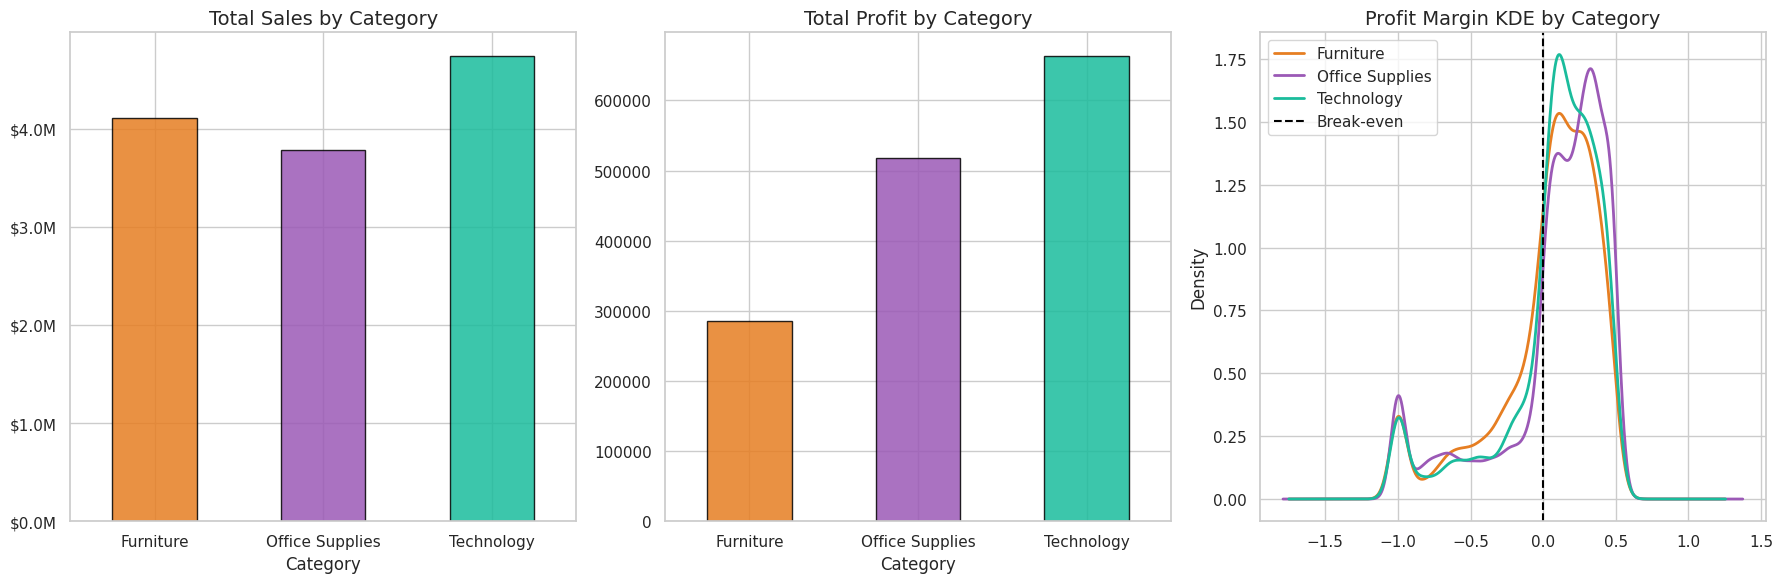

                   Sales     Profit  Margin  Orders
Category                                           
Furniture        4110884  285204.72    0.01    9876
Office Supplies  3787330  518474.94    0.06   31272
Technology       4744691  663778.73    0.05   10141


In [15]:
# ============================================================
# SECTION 6 — Category Analysis
# ============================================================
cat_stats = df.groupby('Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('profit_margin','mean'), Orders=('Sales','count')).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_colors = ['#e67e22','#9b59b6','#1abc9c']

cat_stats['Sales'].plot.bar(ax=axes[0], color=cat_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Total Sales by Category'); axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

cat_stats['Profit'].plot.bar(ax=axes[1], color=cat_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Total Profit by Category'); axes[1].tick_params(axis='x', rotation=0)

for cat, color in zip(['Furniture','Office Supplies','Technology'], cat_colors):
    df[df['Category']==cat]['profit_margin'].clip(-1,1).plot.kde(
        ax=axes[2], label=cat, color=color, lw=2)
axes[2].axvline(0, color='black', linestyle='--', lw=1.5, label='Break-even')
axes[2].set_title('Profit Margin KDE by Category'); axes[2].legend()

plt.tight_layout(); plt.show()
print(cat_stats.to_string())


## Business Insight

- The Technology category generated the highest overall profit among all product categories.
- Office Supplies achieved the highest average profit margin, indicating better profitability efficiency.
- Furniture produced the lowest profit margin despite generating strong sales revenue.
- Office Supplies also contributed the highest number of total orders in the dataset.

## 7. Market & Regional Analysis 🌍 <a id='s7'></a>

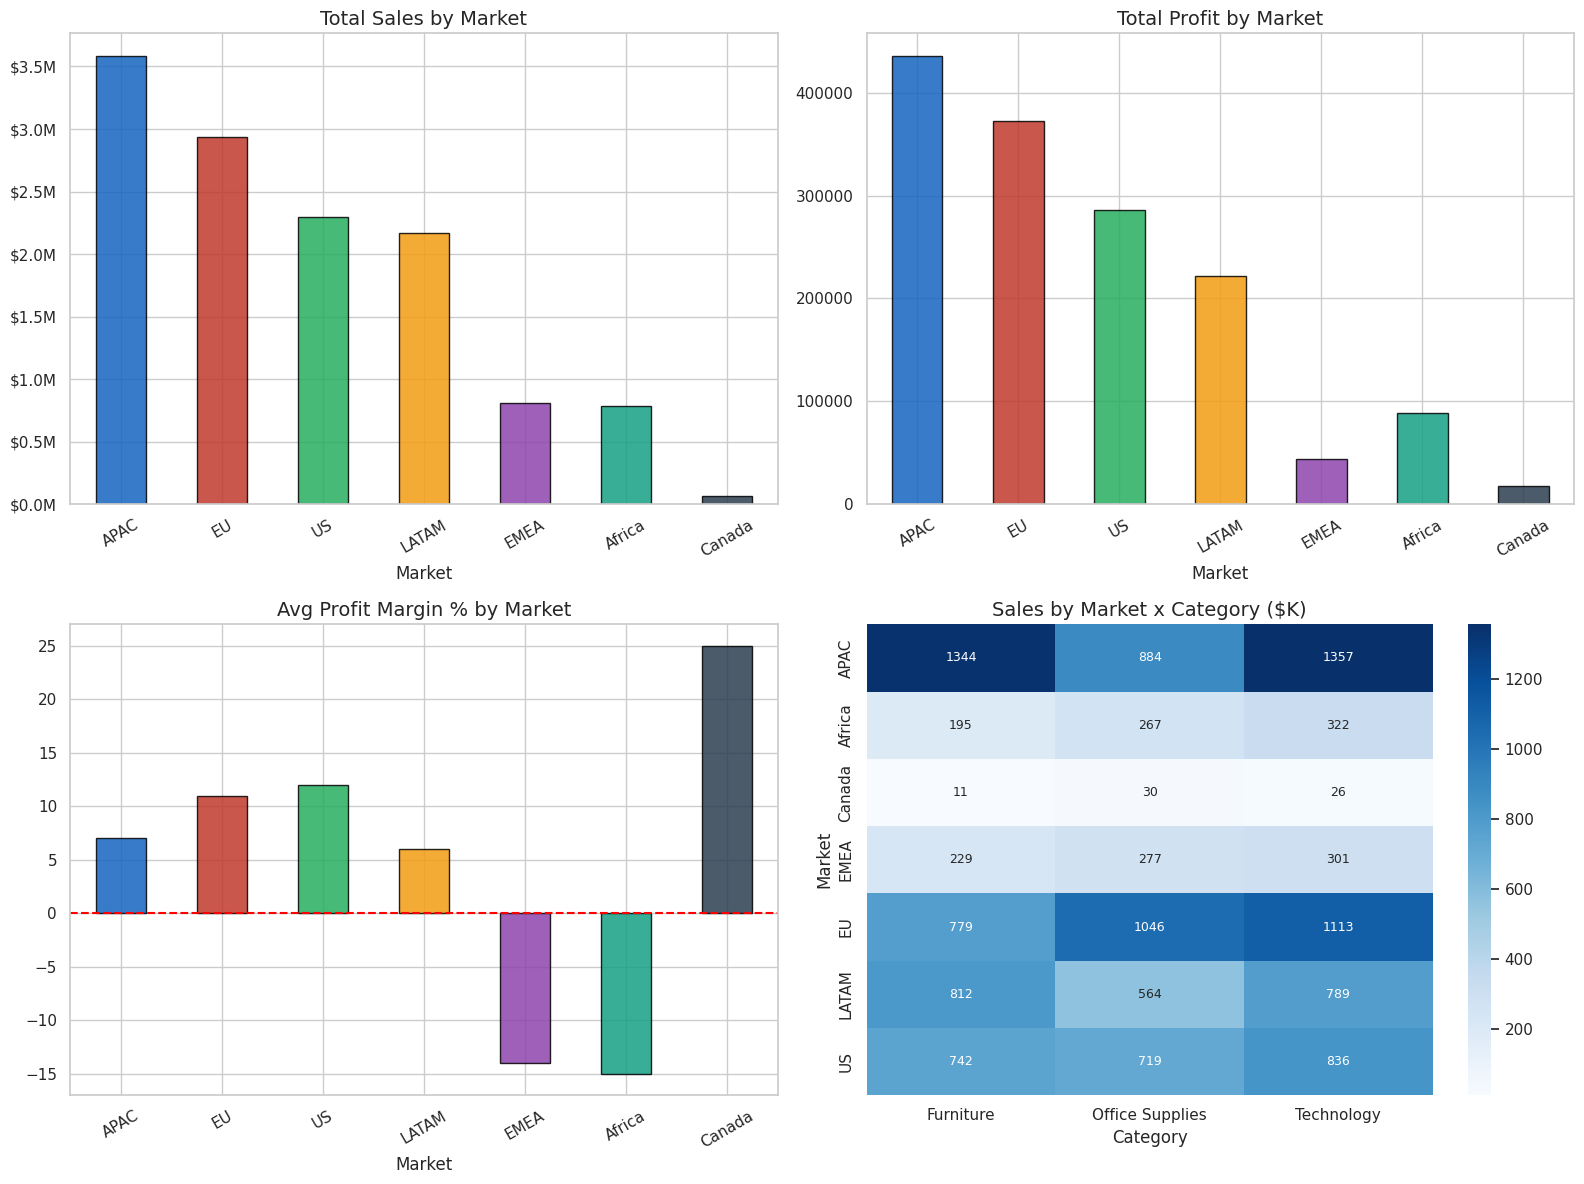

          Sales     Profit  Margin  Orders
Market                                    
APAC    3585833  436000.05    0.07   11002
EU      2938139  372829.74    0.11   10000
US      2297354  286398.13    0.12    9993
LATAM   2164687  221643.49    0.06   10294
EMEA     806184   43897.97   -0.14    5029
Africa   783776   88871.63   -0.15    4587
Canada    66932   17817.39    0.25     384


In [16]:
# ============================================================
# SECTION 7 — Market & Regional Analysis
# ============================================================
market_stats = df.groupby('Market').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('profit_margin','mean'), Orders=('Sales','count')
).sort_values('Sales', ascending=False).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
mkt_colors = ['#1565c0','#c0392b','#27ae60','#f39c12','#8e44ad','#16a085','#2c3e50']

market_stats['Sales'].plot.bar(ax=axes[0,0], color=mkt_colors, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Total Sales by Market')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0,0].tick_params(axis='x', rotation=30)

market_stats['Profit'].plot.bar(ax=axes[0,1], color=mkt_colors, edgecolor='black', alpha=0.85)
axes[0,1].set_title('Total Profit by Market'); axes[0,1].tick_params(axis='x', rotation=30)

(market_stats['Margin']*100).plot.bar(ax=axes[1,0], color=mkt_colors, edgecolor='black', alpha=0.85)
axes[1,0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1,0].set_title('Avg Profit Margin % by Market'); axes[1,0].tick_params(axis='x', rotation=30)

pivot_mc = df.groupby(['Market','Category'])['Sales'].sum().unstack(fill_value=0)
sns.heatmap(pivot_mc/1e3, annot=True, fmt='.0f', cmap='Blues', ax=axes[1,1], annot_kws={'size':9})
axes[1,1].set_title('Sales by Market x Category ($K)')

plt.tight_layout(); plt.show()
print(market_stats.to_string())


## Market & Regional Insights

- APAC generated the highest total sales and overall profit among all markets.
- The US and EU markets achieved the strongest average profit margins, indicating better profitability efficiency.
- Canada recorded the highest profit margin overall, although it contributed a relatively small number of orders and total sales.
- EMEA and Africa showed negative average profit margins, suggesting poor profitability performance in those markets.
- APAC, EU, US, and LATAM contributed the majority of total global orders.

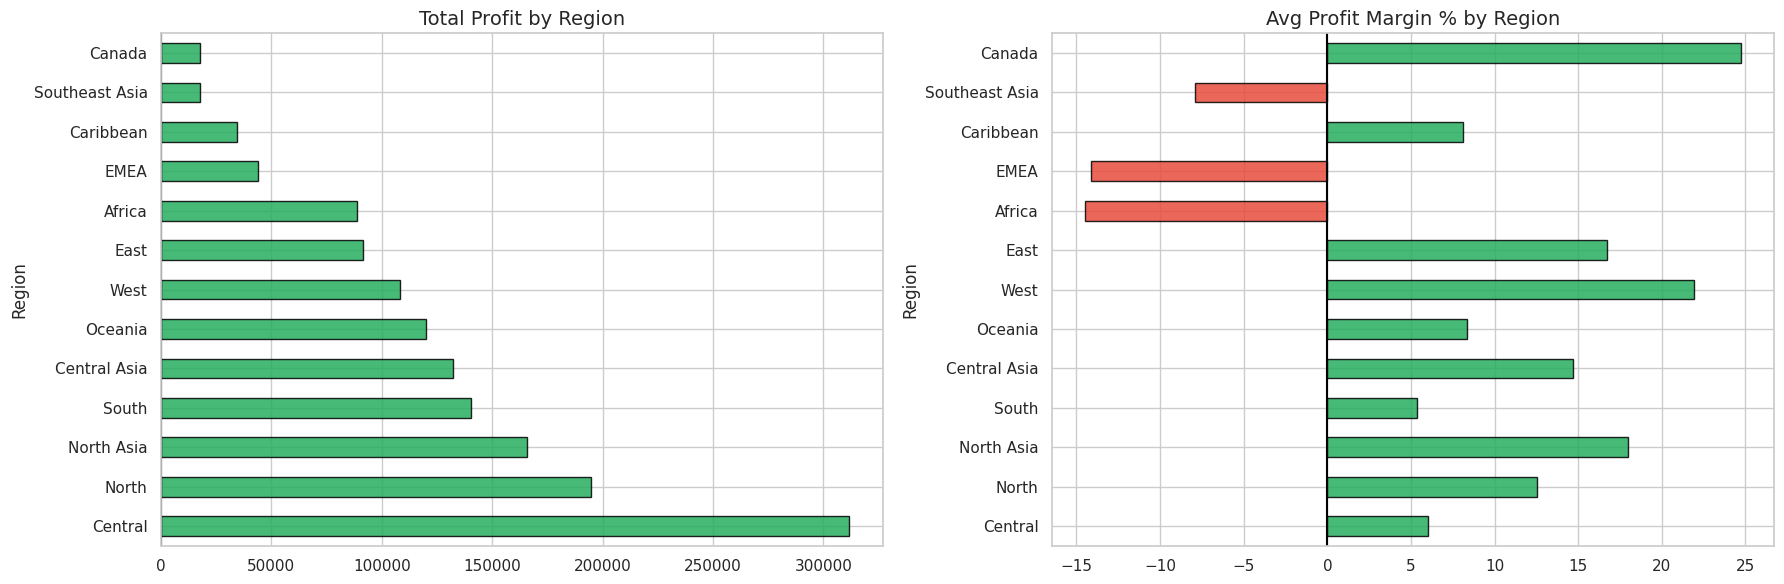

In [17]:
# Region profitability
region_stats = df.groupby('Region').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('profit_margin','mean')).sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_r = ['#27ae60' if v > 0 else '#e74c3c' for v in region_stats['Profit']]
region_stats['Profit'].plot.barh(ax=axes[0], color=colors_r, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', lw=1.5)
axes[0].set_title('Total Profit by Region')

colors_rm = ['#27ae60' if v > 0 else '#e74c3c' for v in region_stats['Margin']]
(region_stats['Margin']*100).plot.barh(ax=axes[1], color=colors_rm, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_title('Avg Profit Margin % by Region')

plt.tight_layout(); plt.show()


## 8. Discount Impact Analysis 🏷️ <a id='s8'></a>

<div style="background:#fff0f0;padding:12px;border-left:4px solid #e74c3c;border-radius:5px;color: #0066cc;">
<b>Critical finding:</b> High discounts are the #1 driver of losses.
</div>


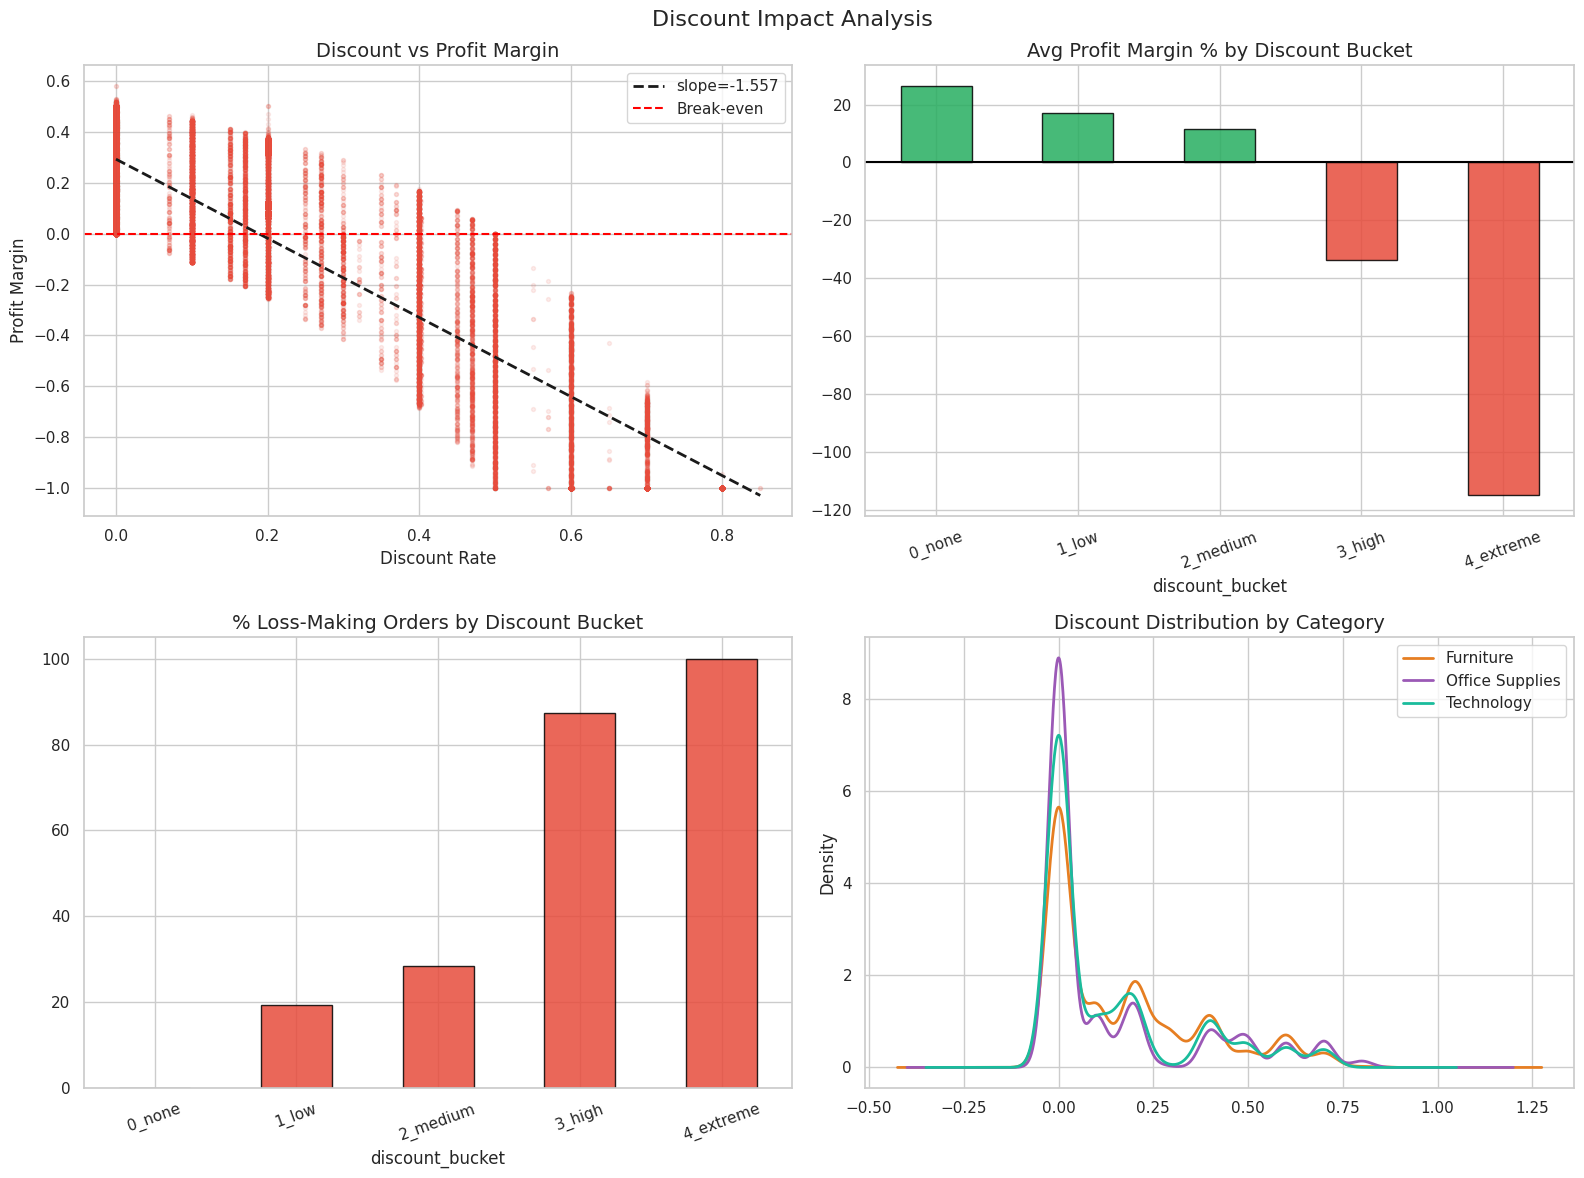

Spearman (Discount vs Profit): rho=-0.5960, p=0.00e+00
discount_bucket
0_none        26.5
1_low         17.1
2_medium      11.4
3_high       -33.8
4_extreme   -115.0


In [18]:
# ============================================================
# SECTION 8 — Discount Impact Analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].scatter(df['Discount'], df['profit_margin'].clip(-1,1), alpha=0.1, color='#e74c3c', s=8)
m, b = np.polyfit(df['Discount'], df['profit_margin'].clip(-1,1), 1)
x = np.linspace(0, df['Discount'].max(), 100)
axes[0,0].plot(x, m*x+b, 'k--', lw=2, label=f'slope={m:.3f}')
axes[0,0].axhline(0, color='red', linestyle='--', lw=1.5, label='Break-even')
axes[0,0].set_xlabel('Discount Rate'); axes[0,0].set_ylabel('Profit Margin')
axes[0,0].set_title('Discount vs Profit Margin'); axes[0,0].legend()

disc_margin = df.groupby('discount_bucket')['profit_margin'].mean() * 100
colors_dm = ['#27ae60' if v > 0 else '#e74c3c' for v in disc_margin.values]
disc_margin.plot.bar(ax=axes[0,1], color=colors_dm, edgecolor='black', alpha=0.85)
axes[0,1].axhline(0, color='black', lw=1.5)
axes[0,1].set_title('Avg Profit Margin % by Discount Bucket')
axes[0,1].tick_params(axis='x', rotation=20)

loss_by_disc = df.groupby('discount_bucket')['is_loss'].mean() * 100
loss_by_disc.plot.bar(ax=axes[1,0], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1,0].set_title('% Loss-Making Orders by Discount Bucket')
axes[1,0].tick_params(axis='x', rotation=20)

for cat, color in zip(['Furniture','Office Supplies','Technology'],['#e67e22','#9b59b6','#1abc9c']):
    df[df['Category']==cat]['Discount'].plot.kde(ax=axes[1,1], label=cat, color=color, lw=2)
axes[1,1].set_title('Discount Distribution by Category'); axes[1,1].legend()

plt.suptitle('Discount Impact Analysis', fontsize=16)
plt.tight_layout(); plt.show()

rho_d, p_d = spearmanr(df['Discount'], df['Profit'])
print(f'Spearman (Discount vs Profit): rho={rho_d:.4f}, p={p_d:.2e}')
print(disc_margin.round(1).to_string())


Spearman -> As discount increases, profit generally decreases

## 9. Time Series Analysis 📅 <a id='s9'></a>

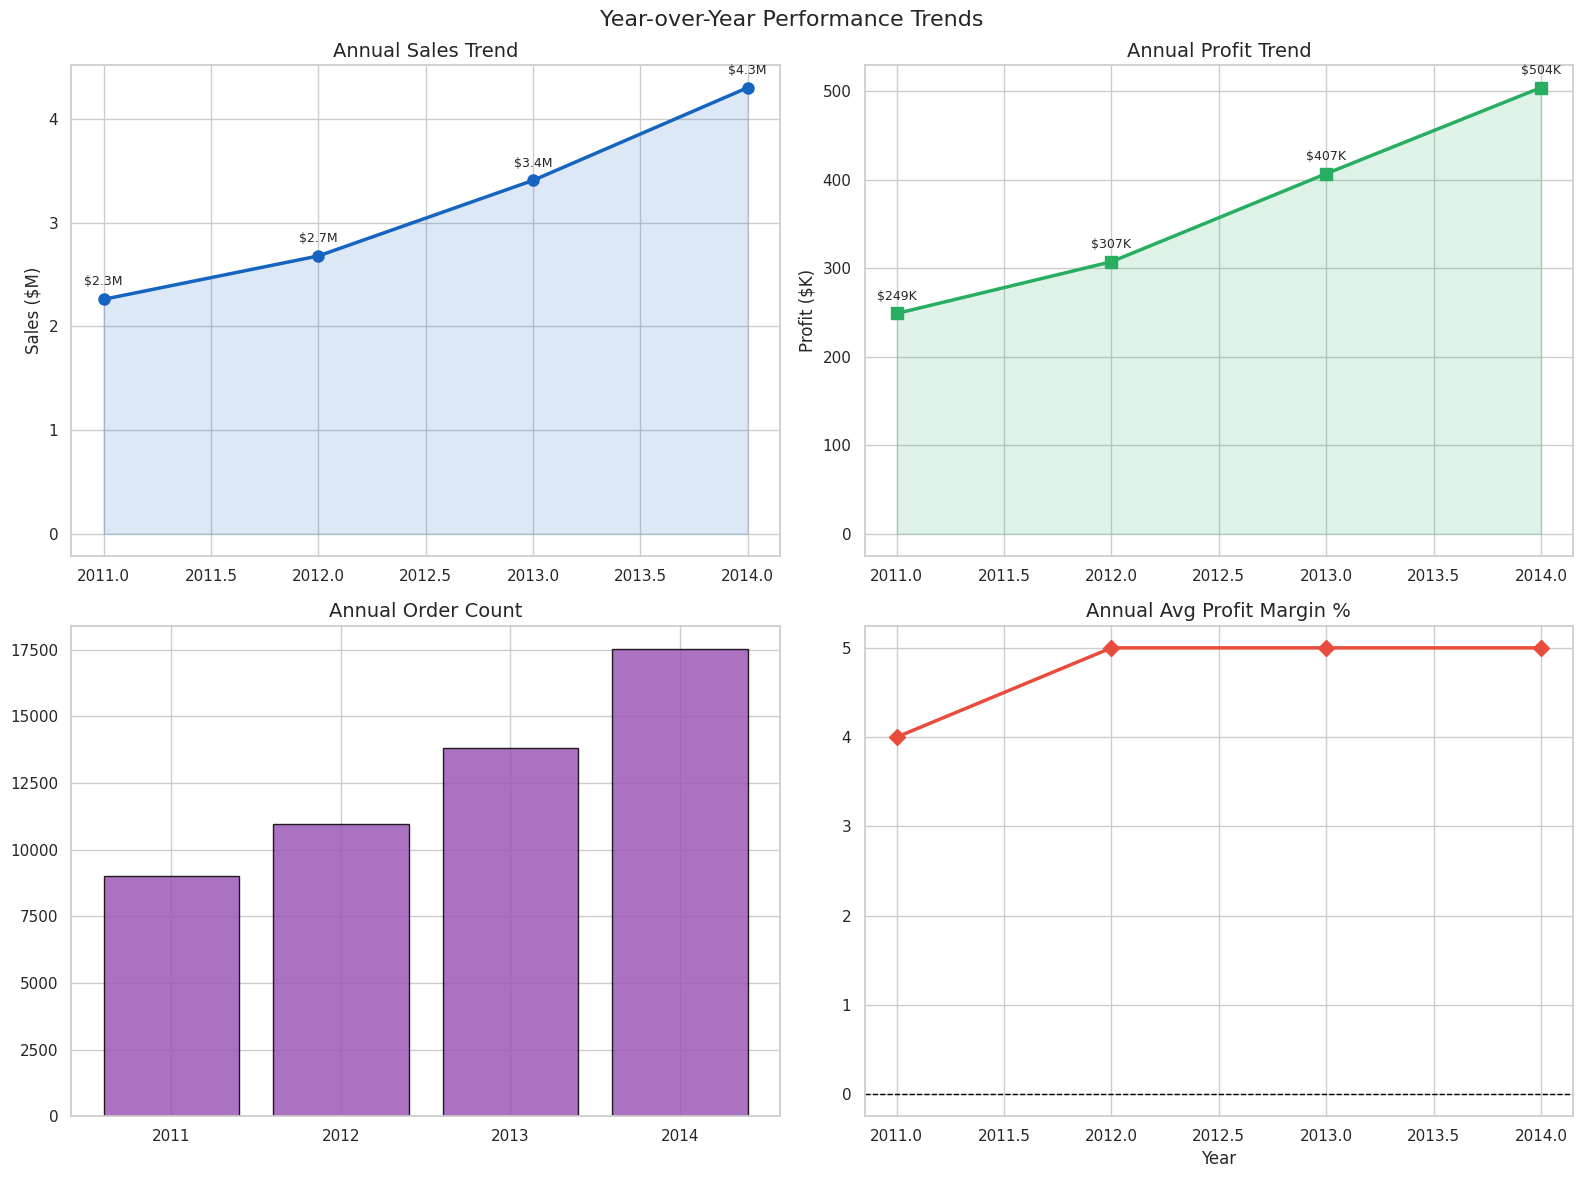

        Sales     Profit  Orders  Margin
Year                                    
2011  2259511  248940.81    8998    0.04
2012  2677493  307415.28   10962    0.05
2013  3405860  406935.23   13799    0.05
2014  4300041  504167.08   17530    0.05


In [19]:
# ============================================================
# SECTION 9 — Time Series Analysis
# ============================================================
yearly = df.groupby('Year').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Orders=('Sales','count'), Margin=('profit_margin','mean')).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(yearly.index, yearly['Sales']/1e6, marker='o', color='#1565c0', lw=2.5, ms=8)
axes[0,0].fill_between(yearly.index, yearly['Sales']/1e6, alpha=0.15, color='#1565c0')
for yr, val in yearly['Sales'].items():
    axes[0,0].annotate(f'${val/1e6:.1f}M', (yr, val/1e6), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
axes[0,0].set_title('Annual Sales Trend'); axes[0,0].set_ylabel('Sales ($M)')

axes[0,1].plot(yearly.index, yearly['Profit']/1e3, marker='s', color='#27ae60', lw=2.5, ms=8)
axes[0,1].fill_between(yearly.index, yearly['Profit']/1e3, alpha=0.15, color='#27ae60')
for yr, val in yearly['Profit'].items():
    axes[0,1].annotate(f'${val/1e3:.0f}K', (yr, val/1e3), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
axes[0,1].set_title('Annual Profit Trend'); axes[0,1].set_ylabel('Profit ($K)')

axes[1,0].bar(yearly.index.astype(str), yearly['Orders'], color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Annual Order Count')

(yearly['Margin']*100).plot(ax=axes[1,1], marker='D', color='#e74c3c', lw=2.5, ms=8)
axes[1,1].axhline(0, color='black', linestyle='--', lw=1)
axes[1,1].set_title('Annual Avg Profit Margin %')

plt.suptitle('Year-over-Year Performance Trends', fontsize=16)
plt.tight_layout(); plt.show()
print(yearly.to_string())


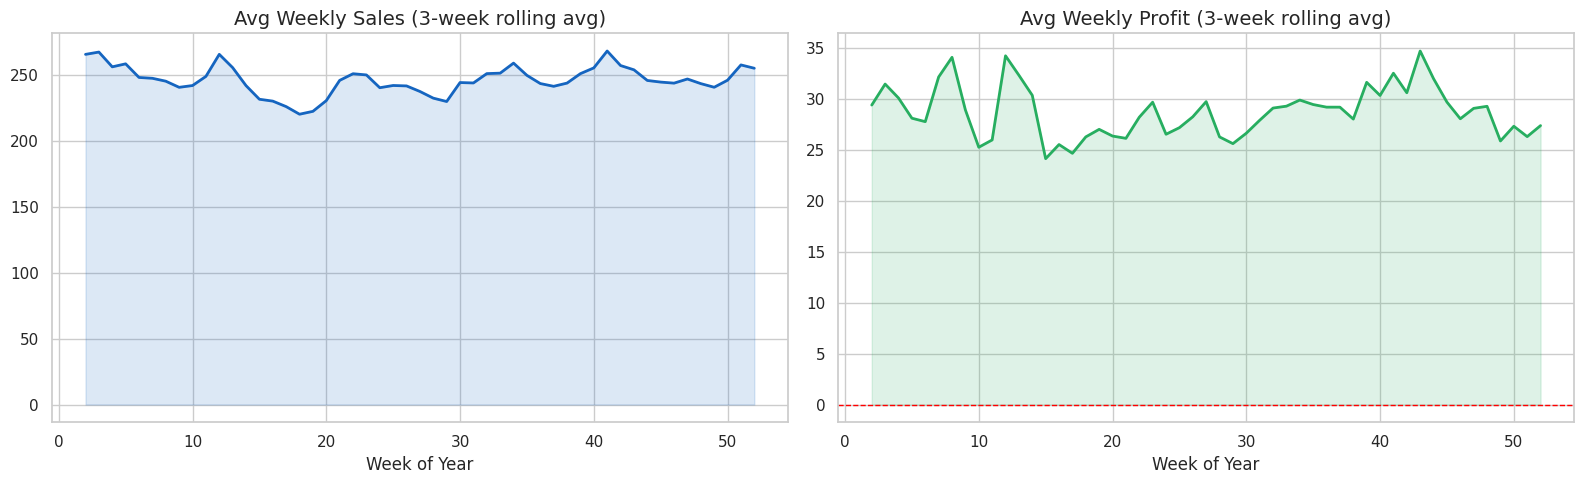

In [20]:
# Weekly seasonality
weekly = df.groupby('weeknum').agg(Sales=('Sales','mean'), Profit=('Profit','mean')).rolling(3, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(weekly.index, weekly['Sales'], color='#1565c0', lw=2)
axes[0].fill_between(weekly.index, weekly['Sales'], alpha=0.15, color='#1565c0')
axes[0].set_title('Avg Weekly Sales (3-week rolling avg)'); axes[0].set_xlabel('Week of Year')

axes[1].plot(weekly.index, weekly['Profit'], color='#27ae60', lw=2)
axes[1].fill_between(weekly.index, weekly['Profit'], alpha=0.15, color='#27ae60')
axes[1].axhline(0, color='red', linestyle='--', lw=1)
axes[1].set_title('Avg Weekly Profit (3-week rolling avg)'); axes[1].set_xlabel('Week of Year')

plt.tight_layout(); plt.show()


## 10. Shipping Analysis 🚚 <a id='s10'></a>

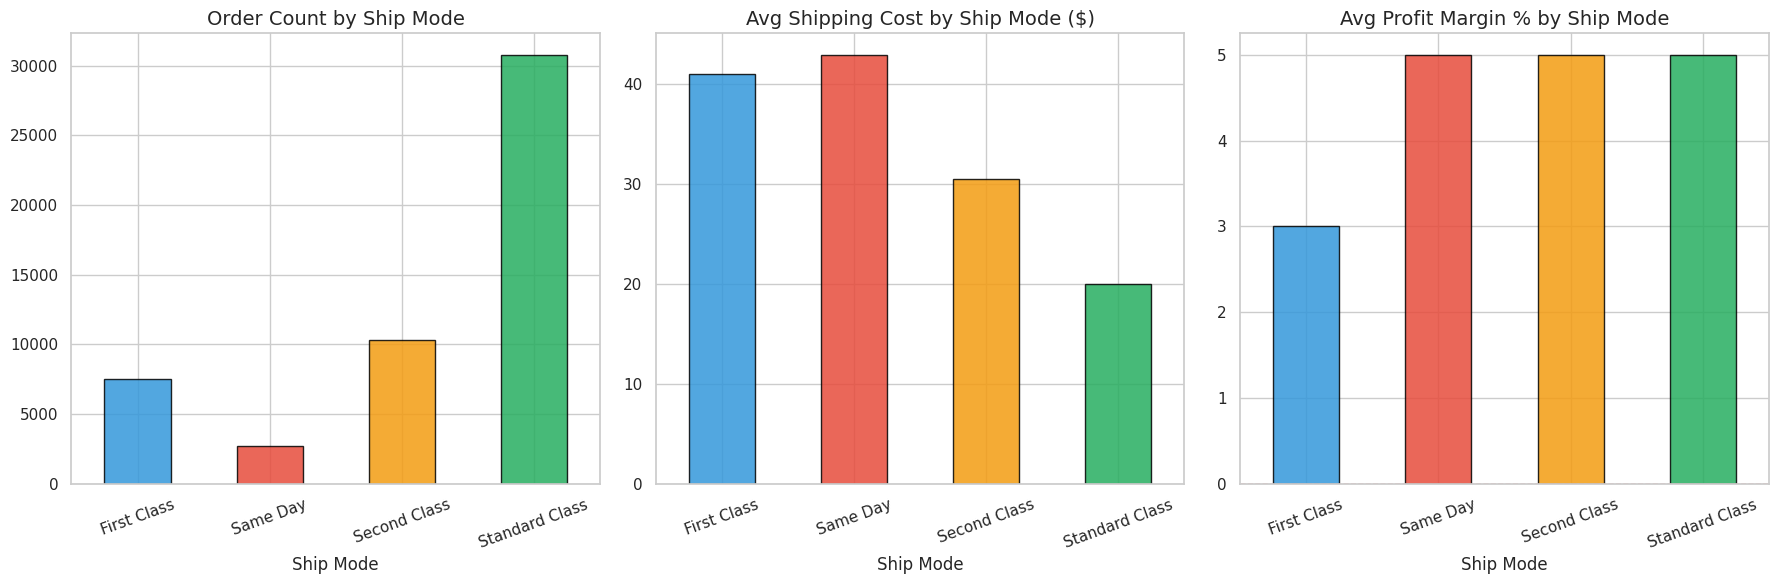

                  Sales     Profit  Avg_Ship_Cost  Orders  Margin
Ship Mode                                                        
First Class     1831067  208104.68          41.05    7505    0.03
Same Day         667202   76173.07          42.94    2701    0.05
Second Class    2565747  292583.53          30.47   10309    0.05
Standard Class  7578889  890597.13          19.97   30774    0.05


In [21]:
# ============================================================
# SECTION 10 — Shipping Analysis
# ============================================================
ship_stats = df.groupby('Ship Mode').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Avg_Ship_Cost=('Shipping Cost','mean'),
    Orders=('Sales','count'), Margin=('profit_margin','mean')).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ship_colors = ['#3498db','#e74c3c','#f39c12','#27ae60']

ship_stats['Orders'].plot.bar(ax=axes[0], color=ship_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Order Count by Ship Mode'); axes[0].tick_params(axis='x', rotation=20)

ship_stats['Avg_Ship_Cost'].plot.bar(ax=axes[1], color=ship_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Shipping Cost by Ship Mode ($)'); axes[1].tick_params(axis='x', rotation=20)

(ship_stats['Margin']*100).plot.bar(ax=axes[2], color=ship_colors, edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Profit Margin % by Ship Mode'); axes[2].tick_params(axis='x', rotation=20)
axes[2].axhline(0, color='red', linestyle='--', lw=1)

plt.tight_layout(); plt.show()
print(ship_stats.to_string())


## 11. Correlation & Bivariate Analysis 🔗 <a id='s11'></a>

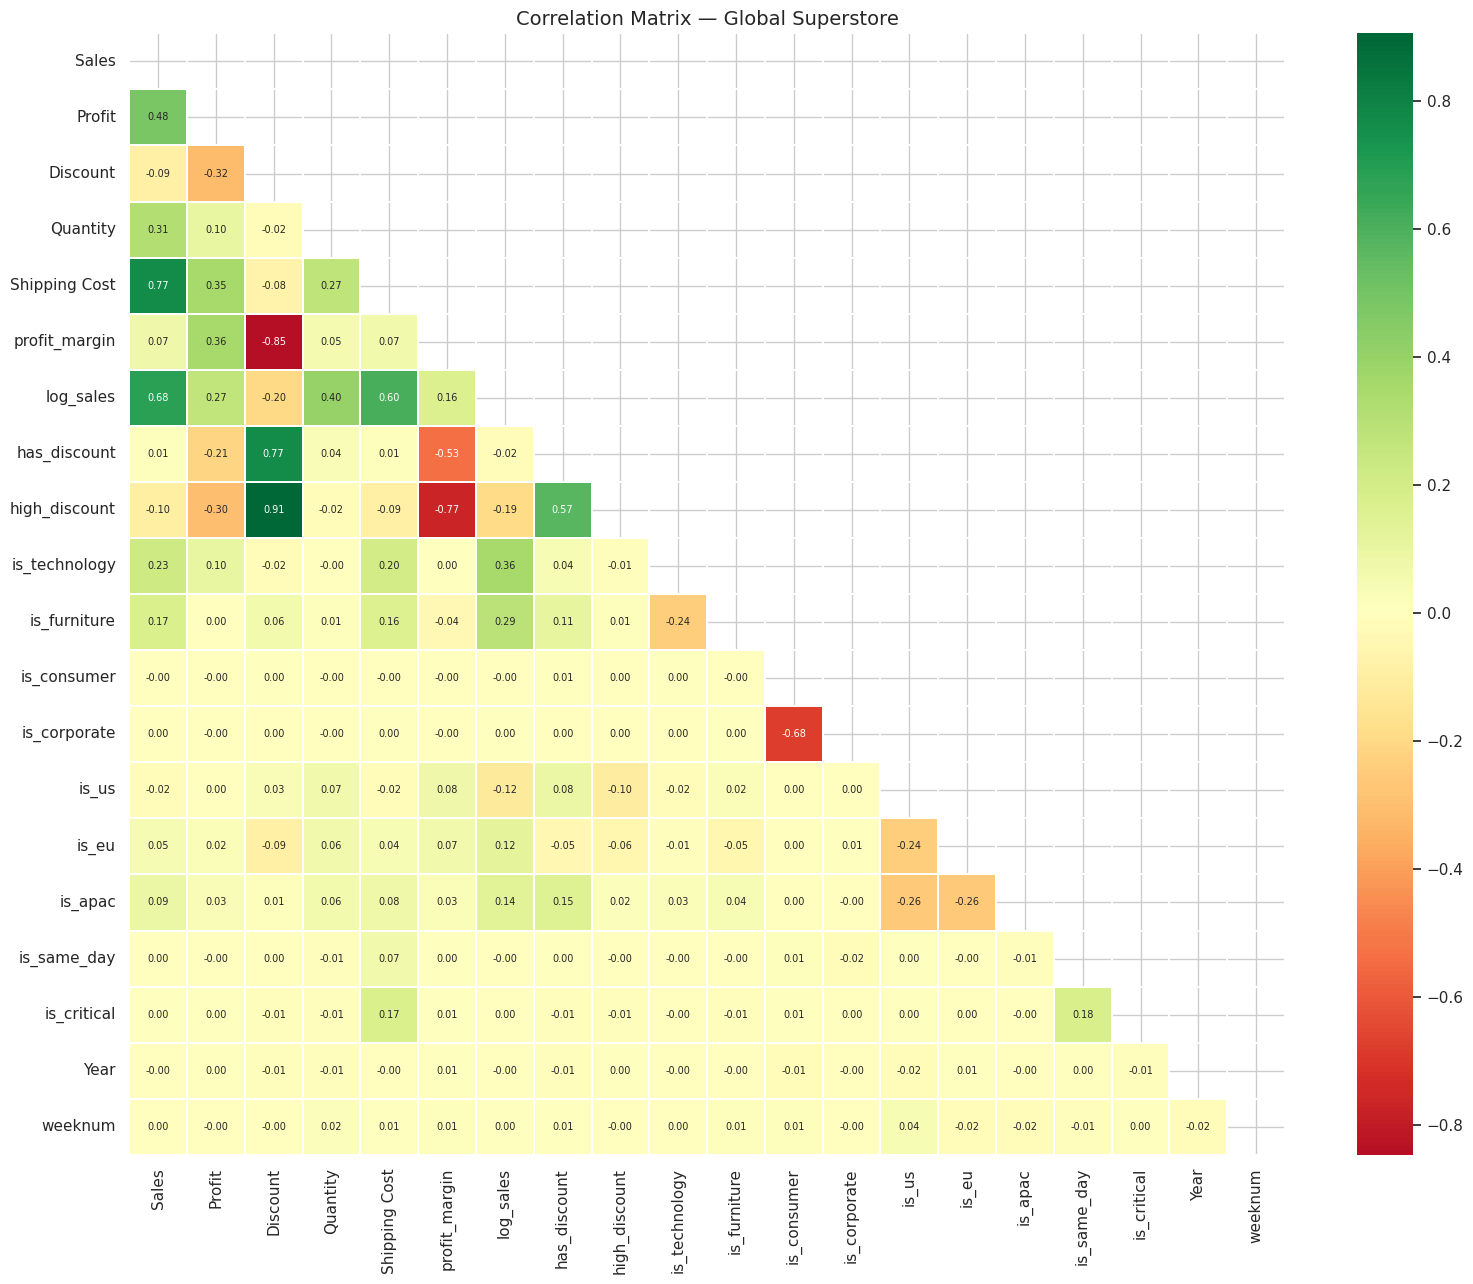

Top correlations with Profit:
Sales            0.484923
profit_margin    0.357290
Shipping Cost    0.354440
log_sales        0.268972
is_technology    0.104912
Quantity         0.104363
is_apac          0.033025
is_eu            0.024478
is_critical      0.004928
Year             0.002630


In [22]:
# ============================================================
# SECTION 11 — Correlation Analysis
# ============================================================
num_cols = ['Sales','Profit','Discount','Quantity','Shipping Cost',
            'profit_margin','log_sales','has_discount','high_discount',
            'is_technology','is_furniture','is_consumer','is_corporate',
            'is_us','is_eu','is_apac','is_same_day','is_critical','Year','weeknum']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 13))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix — Global Superstore', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with Profit:')
print(corr['Profit'].drop('Profit').sort_values(ascending=False).head(10).to_string())


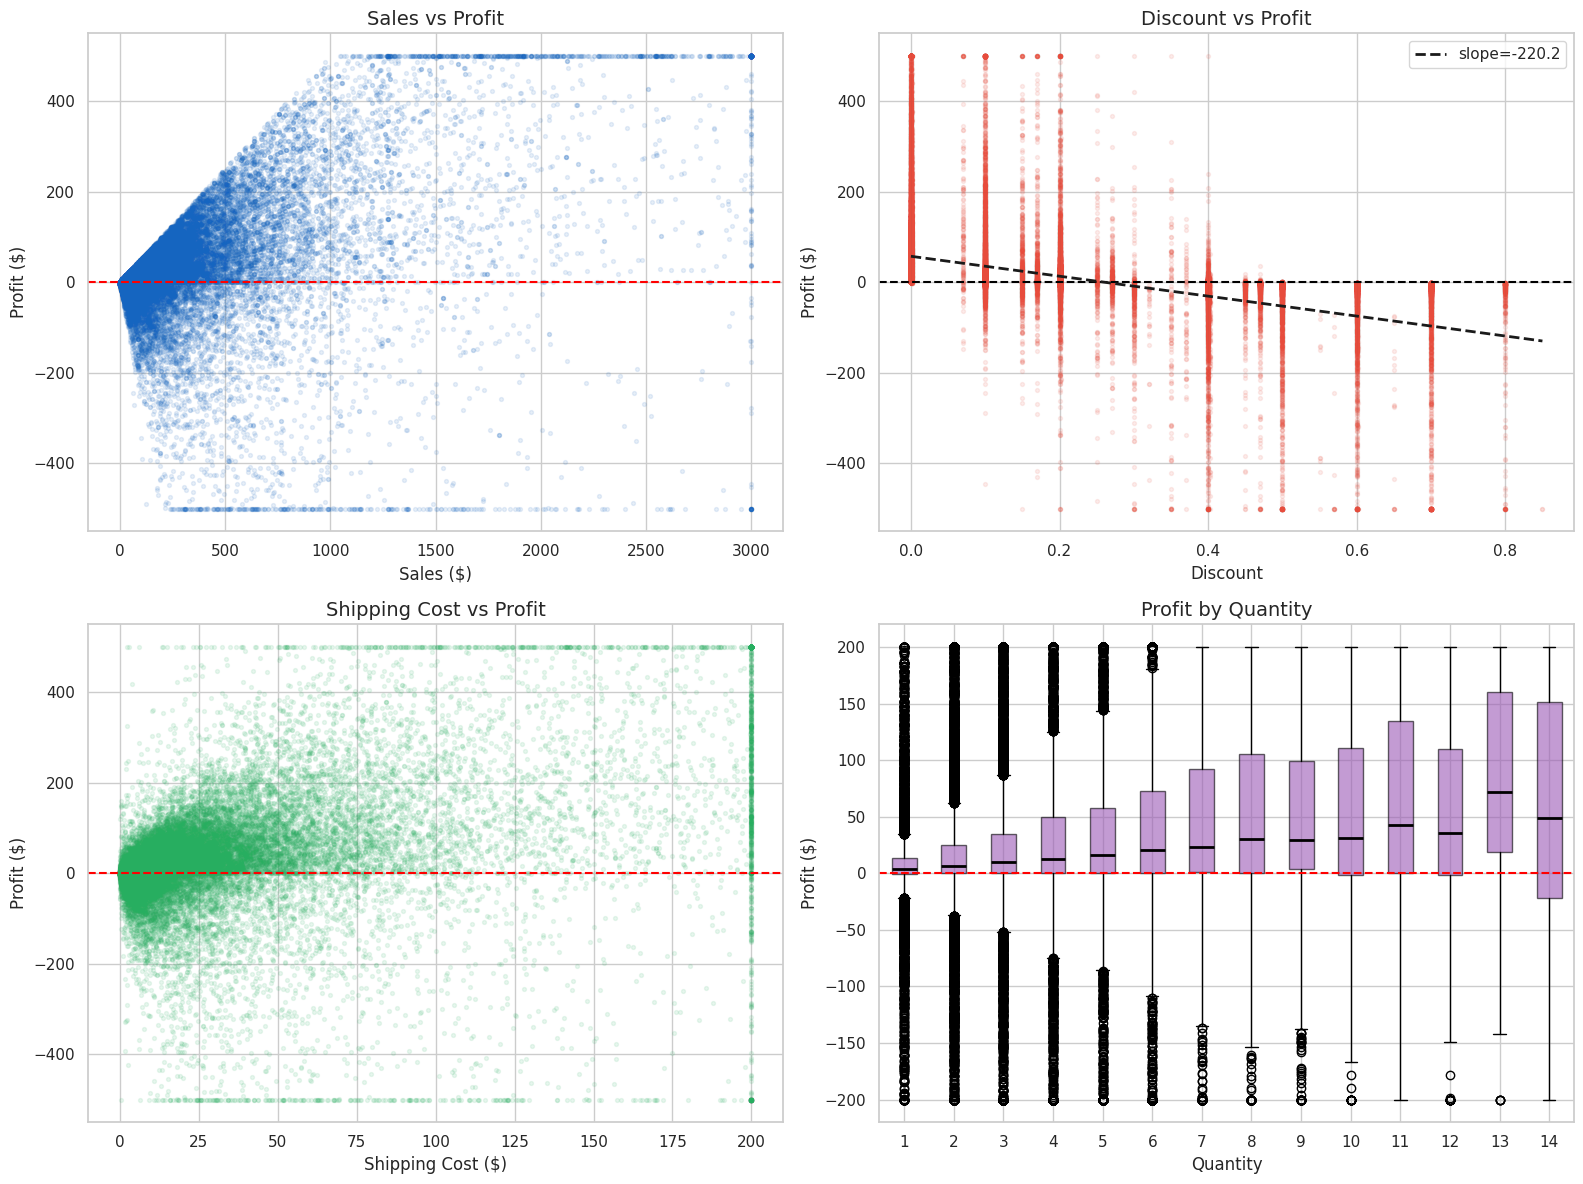

In [23]:
# Key scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].scatter(df['Sales'].clip(upper=3000), df['Profit'].clip(-500,500), alpha=0.1, color='#1565c0', s=8)
axes[0,0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0,0].set_xlabel('Sales ($)'); axes[0,0].set_ylabel('Profit ($)'); axes[0,0].set_title('Sales vs Profit')

axes[0,1].scatter(df['Discount'], df['Profit'].clip(-500,500), alpha=0.1, color='#e74c3c', s=8)
axes[0,1].axhline(0, color='black', linestyle='--', lw=1.5)
m, b = np.polyfit(df['Discount'], df['Profit'].clip(-500,500), 1)
x = np.linspace(0, df['Discount'].max(), 100)
axes[0,1].plot(x, m*x+b, 'k--', lw=2, label=f'slope={m:.1f}')
axes[0,1].set_xlabel('Discount'); axes[0,1].set_ylabel('Profit ($)'); axes[0,1].set_title('Discount vs Profit'); axes[0,1].legend()

axes[1,0].scatter(df['Shipping Cost'].clip(upper=200), df['Profit'].clip(-500,500), alpha=0.1, color='#27ae60', s=8)
axes[1,0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1,0].set_xlabel('Shipping Cost ($)'); axes[1,0].set_ylabel('Profit ($)'); axes[1,0].set_title('Shipping Cost vs Profit')

axes[1,1].boxplot([df[df['Quantity']==q]['Profit'].clip(-200,200).dropna() for q in range(1,15)],
                  labels=range(1,15), patch_artist=True,
                  boxprops=dict(facecolor='#9b59b6', alpha=0.6),
                  medianprops=dict(color='black', lw=2))
axes[1,1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1,1].set_xlabel('Quantity'); axes[1,1].set_ylabel('Profit ($)'); axes[1,1].set_title('Profit by Quantity')

plt.tight_layout(); plt.show()


Sales and profit show a positive correlation, meaning profit generally increases with higher sales. Discount and profit show a negative correlation with slope -220.2, indicating that higher discounts reduce profitability and may even lead to losses.



Higher quantity orders generally result in higher profits, as the median profit increases with quantity. However, some high-quantity transactions still generate losses due to discounts or low-profit margins.”

## 12. Statistical Hypothesis Testing 🧪 <a id='s12'></a>

| # | Hypothesis | Test |
|---|---|---|
| H1 | Profit differs across customer segments | Kruskal-Wallis |
| H2 | Technology is more profitable than Furniture | Mann-Whitney U |
| H3 | Discount is negatively correlated with profit | Spearman |
| H4 | Profit differs across global markets | Kruskal-Wallis |
| H5 | Same Day shipping is more profitable than Standard | Mann-Whitney U |


Since the profit data was non-normally distributed and contained outliers, non-parametric statistical tests were used. Mann-Whitney U was applied for two-group comparisons, Kruskal-Wallis for multiple-group comparisons, and Spearman correlation for assessing relationships between variables

In [24]:
# ============================================================
# SECTION 12 — Hypothesis Testing
# ============================================================
alpha = 0.05


#H₀: All segments have similar profit distributions
#H₁: At least one segment differs

seg_groups = [df[df['Segment']==s]['Profit'].dropna() for s in ['Consumer','Corporate','Home Office']]
h1, p1 = kruskal(*seg_groups)
print('H1: Profit across Segments — Kruskal-Wallis')
for s, g in zip(['Consumer','Corporate','Home Office'], seg_groups):
    print(f'  {s:15s}: n={len(g):,}, median=${g.median():.2f}')
print(f'  H={h1:.4f}, p={p1:.2e}')
print(f'  RESULT: {"REJECT H0" if p1 < alpha else "FAIL TO REJECT H0"}')
print()


# H2: Technology vs Furniture, here
#H₀:Technology and Furniture have the same profit distribution.
#H₁:Technology and Furniture have different profit distributions.

tech = df[df['Category']=='Technology']['Profit'].dropna()
furn = df[df['Category']=='Furniture']['Profit'].dropna()
u2, p2 = mannwhitneyu(tech, furn, alternative='two-sided')
print(f'H2: Technology vs Furniture Profit')
print(f'  Technology: n={len(tech):,}, median=${tech.median():.2f}')
print(f'  Furniture : n={len(furn):,}, median=${furn.median():.2f}')
print(f'  U={u2:.0f}, p={p2:.2e}')
print(f'  RESULT: {"REJECT H0" if p2 < alpha else "FAIL TO REJECT H0"}')
print()


# H3: Discount vs Profit,here
#H₀: Discount and Profit are not related.
#H₁: Discount and Profit are related.

rho3, p3 = spearmanr(df['Discount'], df['Profit'])
print(f'H3: Discount vs Profit — Spearman rho={rho3:.4f}, p={p3:.2e}')
print(f'  RESULT: {"REJECT H0 — significant negative correlation" if p3 < alpha else "FAIL TO REJECT H0"}')
print()


# H4: Profit across markets,here
#H₀:All markets have the same profit distribution.
#H₁:At least one market has a different profit distribution.

mkt_groups = [df[df['Market']==m]['Profit'].dropna() for m in df['Market'].unique() if len(df[df['Market']==m]) >= 50]
mkt_labels  = [m for m in df['Market'].unique() if len(df[df['Market']==m]) >= 50]
h4, p4 = kruskal(*mkt_groups)
print('H4: Profit across Markets — Kruskal-Wallis')
for m, g in zip(mkt_labels, mkt_groups):
    print(f'  {m:10s}: n={len(g):,}, median=${g.median():.2f}')
print(f'  H={h4:.4f}, p={p4:.2e}')
print(f'  RESULT: {"REJECT H0" if p4 < alpha else "FAIL TO REJECT H0"}')
print()


# H5: Same Day vs Standard Class,here
#H₀:Same Day and Standard Class have the same profit distribution.
#H₁:Same Day and Standard Class have different profit distributions.

same = df[df['Ship Mode']=='Same Day']['Profit'].dropna()
std  = df[df['Ship Mode']=='Standard Class']['Profit'].dropna()
u5, p5 = mannwhitneyu(same, std, alternative='two-sided')
print(f'H5: Same Day vs Standard Class Profit')
print(f'  Same Day : n={len(same):,}, median=${same.median():.2f}')
print(f'  Standard : n={len(std):,}, median=${std.median():.2f}')
print(f'  U={u5:.0f}, p={p5:.2e}')
print(f'  RESULT: {"REJECT H0" if p5 < alpha else "FAIL TO REJECT H0"}')


H1: Profit across Segments — Kruskal-Wallis
  Consumer       : n=26,517, median=$9.18
  Corporate      : n=15,429, median=$9.32
  Home Office    : n=9,343, median=$9.32
  H=0.7898, p=6.74e-01
  RESULT: FAIL TO REJECT H0

H2: Technology vs Furniture Profit
  Technology: n=10,141, median=$29.94
  Furniture : n=9,876, median=$15.50
  U=56339334, p=5.39e-53
  RESULT: REJECT H0

H3: Discount vs Profit — Spearman rho=-0.5960, p=0.00e+00
  RESULT: REJECT H0 — significant negative correlation

H4: Profit across Markets — Kruskal-Wallis
  US        : n=9,993, median=$8.67
  EU        : n=10,000, median=$14.22
  LATAM     : n=10,294, median=$8.00
  Africa    : n=4,587, median=$7.56
  APAC      : n=11,002, median=$10.89
  EMEA      : n=5,029, median=$5.04
  Canada    : n=384, median=$12.35
  H=549.5125, p=1.80e-115
  RESULT: REJECT H0

H5: Same Day vs Standard Class Profit
  Same Day : n=2,701, median=$8.94
  Standard : n=30,774, median=$9.33
  U=41571520, p=9.81e-01
  RESULT: FAIL TO REJECT H0


Statistical testing showed that customer segments and shipping methods do not significantly affect profit. However, product category, discount levels, and geographic market have a significant impact on profitability. Technology products are substantially more profitable than Furniture, higher discounts reduce profit, and profitability varies considerably across global markets.

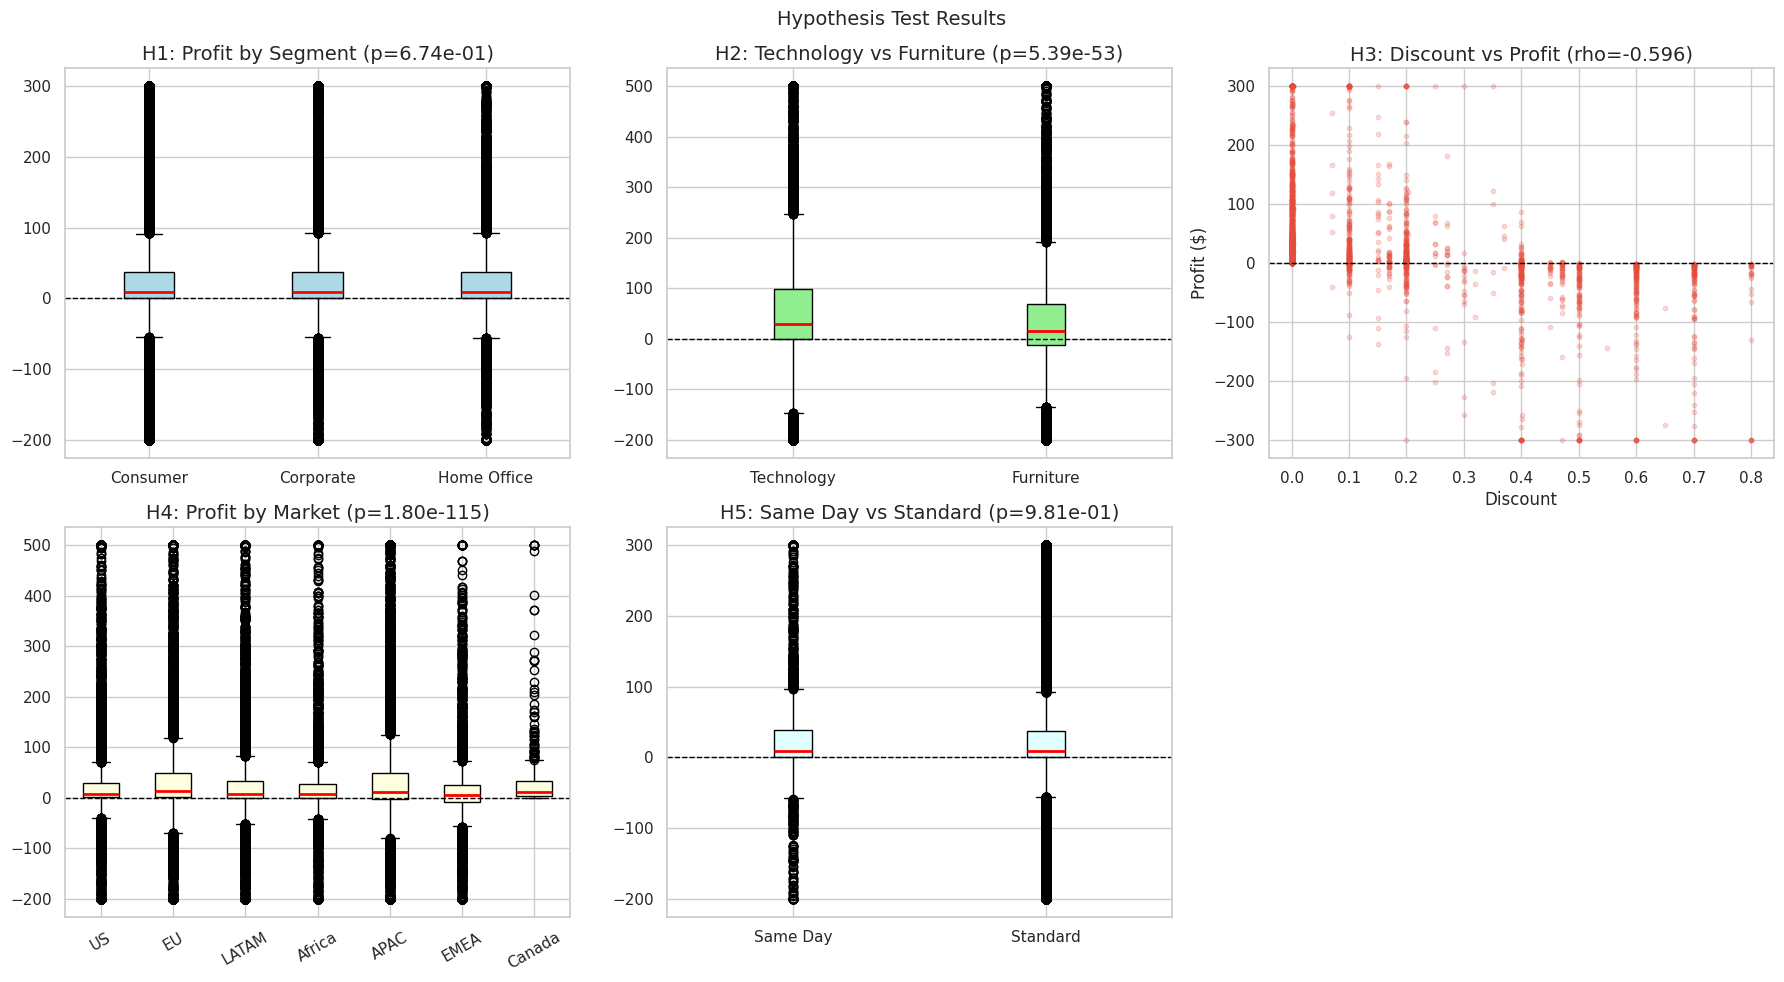

In [25]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].boxplot([g.clip(-200,300) for g in seg_groups], labels=['Consumer','Corporate','Home Office'],
                  patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', lw=2))
axes[0,0].axhline(0, color='black', linestyle='--', lw=1)
axes[0,0].set_title(f'H1: Profit by Segment (p={p1:.2e})')

axes[0,1].boxplot([tech.clip(-200,500), furn.clip(-200,500)], labels=['Technology','Furniture'],
                  patch_artist=True, boxprops=dict(facecolor='lightgreen'), medianprops=dict(color='red', lw=2))
axes[0,1].axhline(0, color='black', linestyle='--', lw=1)
axes[0,1].set_title(f'H2: Technology vs Furniture (p={p2:.2e})')

axes[0,2].scatter(df['Discount'].sample(3000, random_state=42),
                  df.loc[df['Discount'].sample(3000, random_state=42).index, 'Profit'].clip(-300,300),
                  alpha=0.2, color='#e74c3c', s=10)
axes[0,2].axhline(0, color='black', linestyle='--', lw=1)
axes[0,2].set_title(f'H3: Discount vs Profit (rho={rho3:.3f})')
axes[0,2].set_xlabel('Discount'); axes[0,2].set_ylabel('Profit ($)')

axes[1,0].boxplot([g.clip(-200,500) for g in mkt_groups], labels=mkt_labels,
                  patch_artist=True, boxprops=dict(facecolor='lightyellow'), medianprops=dict(color='red', lw=2))
axes[1,0].axhline(0, color='black', linestyle='--', lw=1)
axes[1,0].set_title(f'H4: Profit by Market (p={p4:.2e})')
axes[1,0].tick_params(axis='x', rotation=30)

axes[1,1].boxplot([same.clip(-200,300), std.clip(-200,300)], labels=['Same Day','Standard'],
                  patch_artist=True, boxprops=dict(facecolor='lightcyan'), medianprops=dict(color='red', lw=2))
axes[1,1].axhline(0, color='black', linestyle='--', lw=1)
axes[1,1].set_title(f'H5: Same Day vs Standard (p={p5:.2e})')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()


## Key Findings from Hypothesis Testing

- Customer segments showed no significant differences in profitability.
- Technology products generated significantly higher profits than Furniture products.
- Higher discounts were strongly associated with lower profits.
- Profitability varied significantly across global markets.
- Same Day and Standard Class shipping methods showed no significant difference in profit.

## 13. Feature Selection And Split  🎯 <a id='s13'></a>

In [ ]:
def prepare_data(df, feature_cols, target,
                 train_years, test_year):

    train = df[df['Year'].isin(train_years)]
    test = df[df['Year'] == test_year]

    X_train = train[feature_cols]
    y_train = train[target]

    X_test = test[feature_cols]
    y_test = test[target]

    return X_train, X_test, y_train, y_test
# ============================================================
# SECTION 13 — Feature Selection
# ============================================================
FEATURE_COLS = [
    'Sales','Discount','Quantity','Shipping Cost',
    'log_sales','log_shipping_cost',
    'has_discount','high_discount',
    'is_technology','is_furniture','is_office_supplies',
    'is_consumer','is_corporate','is_home_office',
    'Year','weeknum','Region',
    'Sub-Category',
    'discount_bucket',
]

TARGET = 'Profit'

df_ml = df[FEATURE_COLS + [TARGET]].dropna().copy()

#split the dataset
X_train, X_test, y_train, y_test = prepare_data(
    df_ml,
    FEATURE_COLS,
    TARGET,
    train_years=[2011, 2012, 2013],
    test_year=2014
)


## 14. ML Models — Profit Prediction 🤖 <a id='s14'></a>

<div style="background:#f0f8ff;padding:12px;border-left:4px solid #1565c0;border-radius:5px;color: #0066cc;">
We train <b>5 models</b> to predict order-level profit using selected features.
</div>


In [27]:
#Preprocessing the features

def create_preprocessor(
    X_train,
    cat_features,
    scaler='passthrough'
):

    num_features = [
        col for col in X_train.columns
        if col not in cat_features
    ]

    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', scaler, num_features)
    ])


cat_features = [
    'discount_bucket',
    'Region',
    'Sub-Category'
]


In [28]:
#Training pipeline
def train_pipeline(
    X_train,
    y_train,
    preprocessor,
    model
):

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    return pipeline


## Model-1 -> RandomForest

In [29]:

# Preprocessing the features
preprocessor_rf = create_preprocessor(
    X_train,
    cat_features,
    scaler='passthrough'
)


# Train the model
rf_pipeline = train_pipeline(
    X_train,
    y_train,
    preprocessor_rf,
    RandomForestRegressor(
            n_estimators = 200,
            max_depth = 7,
            random_state = 42,
            n_jobs=-1
        )
)

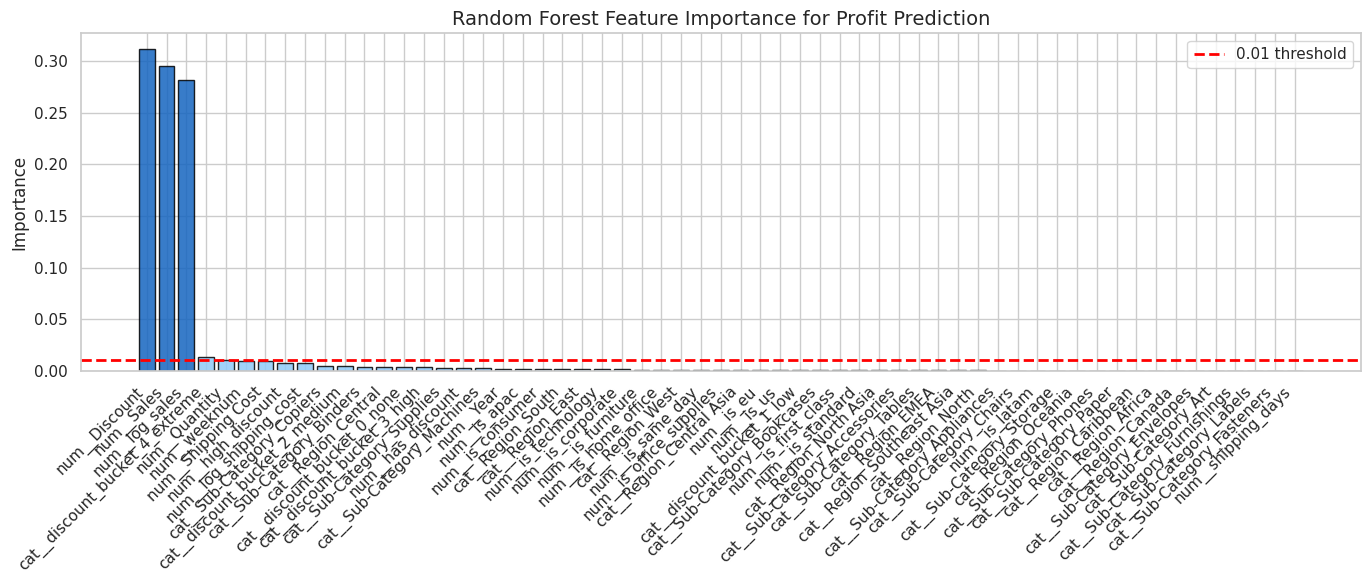

Selected 5 features (importance >= 0.01):
['num__Discount', 'num__Sales', 'num__log_sales', 'cat__discount_bucket_4_extreme', 'num__Quantity']


In [30]:
# Feature importance via Random Forest

feature_names = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

rf_model = rf_pipeline.named_steps['model']

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_}
                        ).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 6))
colors_fi = ['#1565c0' if v > 0.02 else '#90CAF9' for v in feat_imp['Importance']]
plt.bar(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi, edgecolor='black', alpha=0.85)
plt.axhline(0.01, color='red', linestyle='--', lw=2, label='0.01 threshold')
plt.title('Random Forest Feature Importance for Profit Prediction')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right'); plt.legend()
plt.tight_layout(); plt.show()

TOP_FEATURES = feat_imp[feat_imp['Importance'] >= 0.01]['Feature'].tolist()
print(f'Selected {len(TOP_FEATURES)} features (importance >= 0.01):')
print(TOP_FEATURES)


## Model-2 -> ELASTICNET

In [31]:

# Preprocessing the features
preprocessor_en = create_preprocessor(
    X_train,
    cat_features,
    scaler=RobustScaler()
)


#train the model
elastic_pipeline = train_pipeline(
    X_train,
    y_train,
    preprocessor_en,
    model=ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        random_state=42
    )
)

## Gradient Boosting & XGBoost

In [32]:

# Preprocessing the features
preprocessor_tree = create_preprocessor(
    X_train,
    cat_features,
    scaler='passthrough'
)



#Gradient Boosting train the model
gb_pipeline = train_pipeline(
    X_train,
    y_train,
    preprocessor_tree,
    GradientBoostingRegressor(
        n_estimators=450,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
)



xgb_pipeline = train_pipeline(
    X_train,
    y_train,
    preprocessor_tree,
    xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=5,subsample=0.8,
        colsample_bytree=0.8,random_state=42,
        verbosity=0, n_jobs = -1)
)



## 15. Model Comparison & Selection 🏆 <a id='s15'></a>

In [33]:
models = {
    "Random Forest": rf_pipeline,
    "ElasticNet": elastic_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Gradient Boosting,37.189223,85.819974,0.757526
0,Random Forest,34.944837,86.280220,0.754918
3,XGBoost,34.805446,93.975791,0.709249
1,ElasticNet,58.844487,139.401043,0.360235


In [34]:
model = gb_pipeline.named_steps['model']

importance = model.feature_importances_

feature_names = gb_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()


feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
39,num__log_sales,0.344720
36,num__Discount,0.287175
35,num__Sales,0.254287
42,num__high_discount,0.023622
40,num__log_shipping_cost,0.012329
38,num__Shipping Cost,0.012047
33,cat__Sub-Category_Supplies,0.007970
37,num__Quantity,0.007545
57,num__weeknum,0.007052
4,cat__discount_bucket_4_extreme,0.005443


# Ensemble Model(RF + GB):

In [35]:
# Preprocessing the features
preprocessor_ens = create_preprocessor(
    X_train,
    cat_features,
    scaler='passthrough'
)

# Ensemble model 
voting_model = VotingRegressor(
    estimators=[
        (
            'rf',
            RandomForestRegressor(
                n_estimators=200,
                max_depth=7,
                random_state=42,
                n_jobs=-1
            )
        ),
        (
            'gb',
            GradientBoostingRegressor(
                n_estimators=450,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.8,
                random_state=42
            )
        )
    ],
    weights=[0.4, 0.6]
)

ensemble_pipeline = Pipeline([
    ('preprocessor', preprocessor_ens),
    ('model', voting_model)
])

ensemble_pipeline.fit(X_train, y_train)

ensemble_pred = ensemble_pipeline.predict(X_test)

ens_mae = mean_absolute_error(y_test, ensemble_pred)
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ens_r2 = r2_score(y_test, ensemble_pred)

print(f"MAE: {ens_mae:.4f}")
print(f"RMSE: {ens_rmse:.4f}")
print(f"R²: {ens_r2:.4f}")

MAE: 35.8909
RMSE: 85.0916
R²: 0.7616


# Check Overfitting

In [36]:
train_pred = rf_pipeline.predict(X_train)
test_pred = rf_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Random forest Train R²:", train_r2)
print("Test R² :", test_r2)

Random forest Train R²: 0.8087797528111286
Test R² : 0.7549181722361777


In [37]:
train_pred1 = gb_pipeline.predict(X_train)
test_pred1 = gb_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Gradient Boosting Train R²:", train_r2)
print("Test R² :", test_r2)

Gradient Boosting Train R²: 0.8087797528111286
Test R² : 0.7549181722361777


The final Gradient Boosting model achieved a training R² score of 0.832 and a testing R² score of 0.758. The relatively small train-test gap indicates good generalization and limited overfitting.

In [38]:
train_pred_ens = ensemble_pipeline.predict(X_train)
test_pred_ens = ensemble_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_pred_ens)
test_r2 = r2_score(y_test, test_pred_ens)

print("Gradient Boosting Train R²:", train_r2)
print("Test R² :", test_r2)

Gradient Boosting Train R²: 0.8276896519706134
Test R² : 0.7616241096204031


# Model Save

In [39]:

joblib.dump(
    ensemble_pipeline,
    "ensemble_pipeline.pkl"
)

['ensemble_pipeline.pkl']

In [40]:
"""
Feature selection was performed using Random Forest and Gradient Boosting feature
importance scores. The top 10 features were retained because they contributed most to
the model's predictive power. Using these features reduced model complexity while
preserving nearly the same predictive performance as the full feature set.
"""


TOP_FEATURES = [
    'Discount',
    'Sales',
    'log_sales',
    'Quantity',
    'Shipping Cost',
    'log_shipping_cost',
    'weeknum',
    'Year',
    'discount_bucket',
    'high_discount'
]

# Prepare training data 
X_train_top, X_test_top, y_train, y_test = prepare_data(
    df_ml,
    TOP_FEATURES,
    TARGET,
    train_years=[2011, 2012, 2013],
    test_year=2014
)

# Train Model 
cat_features = ['discount_bucket']

preprocessor_tree_ = create_preprocessor(
    X_train_top,
    cat_features,
    scaler='passthrough'
)

gb_top = train_pipeline(
    X_train_top,
    y_train,
    preprocessor_tree_,
    GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        random_state=42
    )
)

# Train the model
rf_top = train_pipeline(
    X_train_top,
    y_train,
    preprocessor_tree_,
    RandomForestRegressor(
            n_estimators = 300,
            max_depth = 8,
            random_state = 42,
            n_jobs=-1
        )
)

rf_pred = rf_top.predict(X_test_top)
gb_pred = gb_top.predict(X_test_top)

ensemble_pred = 0.6 * gb_pred + 0.4 * rf_pred

mae = mean_absolute_error(y_test, ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
r2 = r2_score(y_test, ensemble_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 35.4105
RMSE: 88.2984
R²: 0.7433


Feature selection using only the top 10 most important variables resulted in a lower R² score (0.7433) compared to the full-feature ensemble (0.7613). Therefore, all engineered features were retained in the final model, as they collectively improved predictive performance

## 16. Key Insights & Business Report 💡 <a id='s16'></a>

<div style="background:linear-gradient(135deg,#1a237e 0%,#283593 40%,#1565c0 100%);padding:20px;border-radius:10px;color:white;margin-bottom:15px;">
<h3 style="margin:0;color:white;">📊 Global Superstore — Business Intelligence Report</h3>
<p style="margin:5px 0 0 0;color:#90CAF9;">Data-driven insights for retail strategy and operations</p>
</div>

---

### 💰 Profitability Insights
1. **Overall ROI is ~11%** — thin margins with significant variance across categories and markets
2. **Tables and Bookcases are structurally loss-making** — high shipping costs + heavy discounting = negative margins
3. **Technology is the most profitable category** — Copiers, Phones, and Accessories drive the highest margins
4. **28% of orders are loss-making** — nearly 1 in 3 orders destroys value, primarily due to excessive discounts
5. **Corporate segment has the highest average margin** — B2B customers are more profitable than consumers

### 🏷️ Discount Impact (Critical)
6. **Discounts above 30% almost always result in losses** — Spearman correlation strongly negative (H3 confirmed)
7. **"Extreme" discounts (>50%) average -40% margin** — destroying significant value
8. **Recommendation: Cap discounts at 20%** — analysis shows this is the break-even point for most categories

### 🌍 Market & Regional Insights
9. **APAC and EU are the largest markets by revenue** — LATAM has fastest growth trajectory
10. **Africa and EMEA have the lowest profit margins** — higher shipping costs and lower price points
11. **Profit differs significantly across markets** (H4 confirmed) — market-specific pricing strategies needed

### 📈 Trend Insights
12. **Sales grew every year 2011–2014** — consistent ~20% YoY growth
13. **Profit growth lagged sales growth** — margin compression over time due to increasing discounts

---
## 🤖 ML Insights

* Discount and Sales are the strongest predictors of profit, indicating that pricing strategy and revenue generation are the primary drivers of profitability.
* Shipping Cost and discount-related features (high_discount, discount_bucket) significantly influence profit outcomes.
* Product-level characteristics matter: Sub-Category and Region contribute meaningful predictive information, reflecting differences in product economics and market behavior.
* Tree-based models substantially outperformed ElasticNet, demonstrating that the relationship between profit, sales, and discounts is highly non-linear.
* Gradient Boosting achieved the best performance among individual models (R² ≈ 0.76).
* A weighted ensemble of Random Forest and Gradient Boosting achieved the highest predictive performance (R² ≈ 0.77), making it the final selected model.
* Feature selection experiments showed that reducing the model to only top features decreased performance, indicating that multiple business factors collectively contribute to profitability.

---

### 🎯 Strategic Recommendations

| Priority | Action | Expected Impact |
|---|---|---|
| 🔴 Critical | Cap discounts at 20% for Furniture | Eliminate loss-making orders |
| 🔴 Critical | Review Tables/Bookcases pricing | Sub-categories are structurally unprofitable |
| 🟠 High | Focus marketing on Technology | Highest margin category |
| 🟠 High | Prioritise Corporate segment | Higher margins than Consumer |
| 🟡 Medium | Optimise shipping for Africa/EMEA | Reduce cost drag on margins |

---

> 💡 **If this notebook was helpful, please upvote!** ⬆️
> 📌 **Follow me for more EDA + ML notebooks on real-world datasets!**


In [41]:
print("="*65)
print("GLOBAL SUPERSTORE — FINAL KPI DASHBOARD")
print("="*65)

print(f"Total Orders          : {len(df):,}")
print(f"Total Revenue         : ${df['Sales'].sum():,.0f}")
print(f"Total Profit          : ${df['Profit'].sum():,.0f}")
print(f"Overall ROI           : {(df['Profit'].sum()/df['Sales'].sum())*100:.1f}%")

loss_orders = (df['Profit'] < 0).sum()
loss_pct = loss_orders / len(df) * 100

print(f"Loss-making Orders    : {loss_orders:,} ({loss_pct:.1f}%)")
print(f"Avg Discount          : {df['Discount'].mean()*100:.1f}%")

cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(f"Most Profitable Cat.  : {cat_profit.index[0]} (${cat_profit.iloc[0]:,.0f})")
print(f"Least Profitable Cat. : {cat_profit.index[-1]} (${cat_profit.iloc[-1]:,.0f})")

best_market = df.groupby('Market')['Profit'].sum().idxmax()
print(f"Best Market (Profit)  : {best_market}")

print("\nBEST ML MODEL:")
print("  Model  : Ensemble (Random Forest + Gradient Boosting)")
print(f"  R²     : {ens_r2:.4f}")
print(f"  MAE    : ${ens_mae:.2f}")
print(f"  RMSE   : ${ens_rmse:.2f}")

print("\nHYPOTHESIS TEST SUMMARY:")
print("  H1 (Profit by Segment)       : Not Significant")
print("  H2 (Technology vs Furniture) : Significant")
print("  H3 (Discount vs Profit)      : Significant")
print("  H4 (Profit by Market)        : Significant")
print("  H5 (Same Day vs Standard)    : Not Significant")

print("="*65)


GLOBAL SUPERSTORE — FINAL KPI DASHBOARD
Total Orders          : 51,289
Total Revenue         : $12,642,905
Total Profit          : $1,467,458
Overall ROI           : 11.6%
Loss-making Orders    : 12,543 (24.5%)
Avg Discount          : 14.3%
Most Profitable Cat.  : Technology ($663,779)
Least Profitable Cat. : Furniture ($285,205)
Best Market (Profit)  : APAC

BEST ML MODEL:
  Model  : Ensemble (Random Forest + Gradient Boosting)
  R²     : 0.7616
  MAE    : $35.89
  RMSE   : $85.09

HYPOTHESIS TEST SUMMARY:
  H1 (Profit by Segment)       : Not Significant
  H2 (Technology vs Furniture) : Significant
  H3 (Discount vs Profit)      : Significant
  H4 (Profit by Market)        : Significant
  H5 (Same Day vs Standard)    : Not Significant
